# 第二組 Project 3
組員：莊雅筑、胡新容、劉芊妤、許鉦偉、陳孝杰、陳柏勳、藍立衡、龍健銘

# 第十一週：Text Embeddings

本週課程為「Text Embeddings」，主要會使用到gensim套件來實現自行訓練word2vec模型以及使用預訓練word2vec模型，以及透過sentence-transformers套件和API取得embeddings。

### 大綱：
1.   DEMO
*   Word2Vec
  *   自己訓練w2v模型
  *   使用別人訓練好的w2v模型
*   Transformers Embeddings
  *   小模型（BERT）：
      *   不同語言的BERT：uncased / chinese / multilingual
  *   大模型（LLM）：
      *   API based
      *   Open Source LLM  

2.   資料集實作任務
*    使用embedding 做 NLP 任務
  *   找相似文件（文章）
  *   文件分類任務

### 套件安裝

In [38]:
# !pip install jieba
# !pip install "gensim==4.3.3" "spacy==3.7.2" "thinc==8.2.2"
# !pip install plotly

In [39]:
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np
from collections import defaultdict
import multiprocessing

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors


import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import torch

from matplotlib.font_manager import fontManager
import plotly.express as px

sns.set_style("darkgrid")

### 資料前處理

讀入吃到飽示範資料集

In [40]:
# 設定繁體中文詞庫
jieba.set_dictionary('dict\dict.txt')
jieba.load_userdict('./dict/user_dict.txt')

# 新增stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

Building prefix dict from c:\Users\User\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u39b885617fea8e30e122529cfb9d1eb6.cache
Loading model cost 0.337 seconds.
Prefix dict has been built successfully.


In [41]:
# 斷詞函式
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [42]:
# 讀入中文示範資料集
origin_data = pd.read_csv('raw_data/starlux_dataset.csv')

In [43]:
# 資料前處理

# 去除一些不需要的欄位
# metaData = origin_data.drop(['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], axis=1)
# 修改後的寫法
metaData = origin_data.drop(
    ['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], 
    axis=1, 
    errors='ignore'
)
# 只留下中文字
metaData['sentence'] = metaData['artContent'].str.replace(r'\n\n','。', regex=True)
metaData['sentence'] = metaData['sentence'].str.replace(r'\n','', regex=True)

metaData['sentence'] = metaData['sentence'].str.split("[,，。！!？?]{1,}")
metaData = metaData.explode('sentence').reset_index(drop=True)

metaData['sentence'] = metaData['sentence'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

metaData['word'] = metaData.sentence.apply(getToken)

metaData = metaData[metaData['word'].apply(len) > 0]

metaData.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artContent,sentence,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢,"[請問, 新加坡, 台灣, 星宇星, 加坡, 長榮]"
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星宇累計的里程和星加坡長榮應該是分開的,"[票價, 星宇, 便宜, 明白, 那麼多, 選星宇, 累計, 里程, 加坡, 長榮, 分開]"
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話,[位置]
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢還是都用班機時刻選請問大家會怎麼選感謝,"[這三家, 班機, 時刻, 請問, 感謝]"
4,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的,"[這有, 糾結]"
5,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,你沒高卡沒哩程需求就是選便宜的啊,"[沒高卡, 哩程, 需求, 便宜]"
6,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,"[星宇, 看到, 托運, 一件, 最近, 注意到]"
7,3,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:54,comment,金城武都選長榮 你參考,金城武都選長榮你參考,"[金城武, 長榮, 參考]"
8,4,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 17:09,comment,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到,"[哩程, 卡客, 便宜, 便宜, 低價票, 設定, 促銷, 票給, 看到]"
10,6,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 18:28,comment,台灣新加坡航線，不管什麼航空基本票價都是一件行李,台灣新加坡航線,"[台灣, 新加坡, 航線]"


### word2vec

####（1）如何自己訓練word2vec模型

建立訓練資料時將考慮bigram，以下為Phrases函式的使用示範

In [44]:
docs = ['new york is united states', 'new york is most populated city in the world','i love to stay in new york']

token_ = [doc.split(" ") for doc in docs]
# Phrases 建立bigram,
# 少於min_count的字的字或bigrams會被忽略,
# 大於threshold的bigrams會被加入
bigram = Phrases(token_, min_count=1, threshold=2)
bigram_phraser = Phraser(bigram)

for sent in token_:
    print(sent)  #處理前
    print("=> ",bigram_phraser[sent]) # 處理後，還是原本的句子，只是有抓出的bigram片語會被合併

['new', 'york', 'is', 'united', 'states']
=>  ['new_york', 'is', 'united', 'states']
['new', 'york', 'is', 'most', 'populated', 'city', 'in', 'the', 'world']
=>  ['new_york', 'is', 'most', 'populated', 'city', 'in', 'the', 'world']
['i', 'love', 'to', 'stay', 'in', 'new', 'york']
=>  ['i', 'love', 'to', 'stay', 'in', 'new_york']


實際應用在資料集上

In [45]:
sents = metaData['word'].to_list()
bigrams = Phrases(sents,min_count=1, threshold=1000)
bigram_phrasers = Phraser(bigrams)
metaData['word_list_bigrams'] = list(bigram_phrasers[sents])

metaData.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artContent,sentence,word,word_list_bigrams
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢,"[請問, 新加坡, 台灣, 星宇星, 加坡, 長榮]","[請問, 新加坡, 台灣, 星宇星, 加坡, 長榮]"
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星宇累計的里程和星加坡長榮應該是分開的,"[票價, 星宇, 便宜, 明白, 那麼多, 選星宇, 累計, 里程, 加坡, 長榮, 分開]","[票價, 星宇, 便宜, 明白, 那麼多, 選星宇, 累計, 里程, 加坡, 長榮, 分開]"
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話,[位置],[位置]
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢還是都用班機時刻選請問大家會怎麼選感謝,"[這三家, 班機, 時刻, 請問, 感謝]","[這三家, 班機, 時刻, 請問, 感謝]"
4,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的,"[這有, 糾結]","[這有, 糾結]"


In [46]:
word_freq = defaultdict(int)
# 計算詞頻
sents = metaData['word_list_bigrams'].tolist()
for sent in sents: # sent 中的每個句子
    for i in sent: # i 是句子中的每個字
        word_freq[i] += 1

In [47]:
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

total unique words in sentences: 10189


['星宇', '員工', '公司', '年終', '飛機', '華航', '長榮', '台中', '星宇航空', '航空']

In [48]:
print(f"sentence number of corpus: {len(sents)}")
i = 0
for sent in sents:
    i = i + len(sent)
print(f"average length of sentences: {i/len(sents)}")

sentence number of corpus: 9225
average length of sentences: 4.182655826558266


Word2Vec 計算

In [49]:
# 環境變數設定
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [50]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 16


In [51]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=20,# 小於20次tf的字會被刪除
                     window=2,# 往左右各2的距離
                     vector_size=128,# vector 的維度
                     sample=0.005,# 愈小的話，高tf的字會不容易被選到
                     alpha=0.001,# learning rate
                     min_alpha=0.0005, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1, # 用的cpu資源
                     seed=8787,
                     sg = 1,# 0/1 是否使用skip gram
                     epochs= 30,
                     hs=1 , # hierarchical softmax
                     )

查看結果

In [52]:
# 檢查最相關的字
w2v_model.wv.most_similar('飛機',topn=10)

[('長榮', 0.5823999047279358),
 ('知道', 0.5459326505661011),
 ('公司', 0.5328293442726135),
 ('精品', 0.5290846228599548),
 ('航空公司', 0.5272822976112366),
 ('折舊', 0.5268827676773071),
 ('日本', 0.5244141817092896),
 ('現在', 0.5193042159080505),
 ('賺錢', 0.5051112771034241),
 ('不用', 0.5002626180648804)]

In [53]:
w2v_model.wv.most_similar('年終',topn=10)

[('公司', 0.8945971727371216),
 ('員工', 0.8945363759994507),
 ('引述', 0.840484082698822),
 ('資方', 0.8323033452033997),
 ('台灣', 0.8313009142875671),
 ('銘言', 0.8302370309829712),
 ('不發', 0.8153390288352966),
 ('國泰', 0.8135673999786377),
 ('看到', 0.8094696402549744),
 ('商務艙', 0.80072021484375)]

In [54]:
w2v_model.wv.most_similar(['員工','年終'],topn=10)

[('公司', 0.913510262966156),
 ('台灣', 0.8528666496276855),
 ('引述', 0.8518081307411194),
 ('資方', 0.8459905385971069),
 ('不發', 0.8454709053039551),
 ('銘言', 0.8373059630393982),
 ('國泰', 0.8358669877052307),
 ('看到', 0.8306534290313721),
 ('罷工', 0.8213186264038086),
 ('航線', 0.8206555843353271)]

In [55]:
# 跟兩個字最不相關
w2v_model.wv.most_similar(negative=['年終','飛機'],topn=10)

[('旅客', 0.7036125063896179),
 ('新聞', 0.6297901272773743),
 ('原文', 0.5906305313110352),
 ('桃園', 0.5669176578521729),
 ('發現', 0.48746025562286377),
 ('競爭', 0.4629436135292053),
 ('客人', 0.4418061077594757),
 ('尤其', 0.4311889111995697),
 ('加入', 0.4048938751220703),
 ('原來', 0.3921820819377899)]

In [56]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("年終","長榮")

0.6421058

In [57]:
w2v_model.wv.similarity("星宇","飛機")

0.39477992

In [58]:
# 比較字詞間，誰最不相關（邊緣）
w2v_model.wv.doesnt_match(["年終", "星宇", '飛機'])

'飛機'

In [59]:
# 相對關係
w2v_model.wv.most_similar(positive=["年終"], negative=["星宇"], topn=5)

[('新創', 0.34083104133605957),
 ('日期', 0.3404657542705536),
 ('來源', 0.32046157121658325),
 ('老闆', 0.31292229890823364),
 ('共體時艱', 0.30933547019958496)]

In [60]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

視覺化字之間的關係及將字做分群


In [61]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat


In [62]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)


In [63]:
getVecs(w2v_model,['年終','星宇'])

array([[ 4.53174289e-04,  2.01107748e-02, -2.20597794e-04,
         1.83557216e-02,  3.43062393e-02, -1.21456143e-02,
         4.76083905e-03, -2.11362028e-03,  1.12762544e-02,
        -3.38825048e-03,  8.78943969e-03, -2.81915837e-03,
        -1.37978224e-02, -9.00225807e-03, -2.36841869e-02,
         3.97519320e-02,  1.42028071e-02,  1.31371878e-02,
        -1.21040763e-02,  1.09633869e-02, -1.37229133e-02,
        -1.81418266e-02,  1.82105917e-02, -4.50428203e-02,
        -6.14416273e-03,  2.30008382e-02, -2.33480725e-02,
         1.29439142e-02,  1.76535174e-02, -8.39861017e-03,
         1.19891362e-02,  1.85262691e-02,  3.39869817e-04,
         2.79975701e-02,  7.19179213e-03,  2.22162856e-03,
         1.26824062e-02, -2.34381575e-02, -1.08366534e-02,
        -3.39882029e-03,  2.04389822e-02, -1.42060099e-02,
         4.61383536e-03, -1.88215228e-04, -7.29492074e-03,
        -3.16497707e-03,  1.41764376e-02,  2.20756978e-02,
        -9.03791841e-03, -7.59296073e-03,  3.18953060e-0

In [64]:
# 擴展相似的字詞
def expandPosWord(model, words:list, top_n:int, split = True):

    if split == False:
        wp = model.wv.most_similar(words,topn = top_n)
        return wp
    expand = []

    for w in words:
        wp = model.wv.most_similar(w,topn = top_n)
        for i in wp:
            expand.append(i[0])

    return list(set(expand))


In [65]:
expandPosWord(w2v_model,['年終','飛機'],top_n = 10)

['商務艙',
 '看到',
 '資方',
 '賺錢',
 '日本',
 '知道',
 '現在',
 '公司',
 '銘言',
 '引述',
 '不用',
 '長榮',
 '折舊',
 '員工',
 '台灣',
 '精品',
 '國泰',
 '航空公司',
 '不發']

In [66]:
# 畫出兩維的散佈圖
def plotScatter(vec_df):
    """
    vec_df: 字詞及其兩個維度的值
    """
    plt.figure(figsize=(15,15))
    fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
    plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
    plt.rcParams['font.size'] = '16'

    p = sns.scatterplot(x="dim1", y="dim2",
                  data=vec_df)
    for line in range(0, vec_df.shape[0]):
         p.text(vec_df["dim1"][line],
                 vec_df['dim2'][line],
                 '  ' + vec_df["word"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 weight='normal'
                ).set_size(15)
    plt.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [67]:
# 查看總數
total_words = len(words)
print(f"目前詞庫總數：{total_words}")

# 查看前 20 個詞（確認過濾邏輯是否正確）
print("詞庫樣本：", list(words)[:20])

目前詞庫總數：318
詞庫樣本： ['星宇', '員工', '公司', '年終', '飛機', '華航', '長榮', '台中', '星宇航空', '航空', '罷工', '知道', '航線', '台灣', '現在', '賺錢', '問題', '日本', '商務艙', '頭等艙']


In [68]:
sample_words = np.random.choice(list(words),300,replace=False).tolist()

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 300)
print(new_feat.shape)

(300, 128)
(300, 2)


In [69]:
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
})

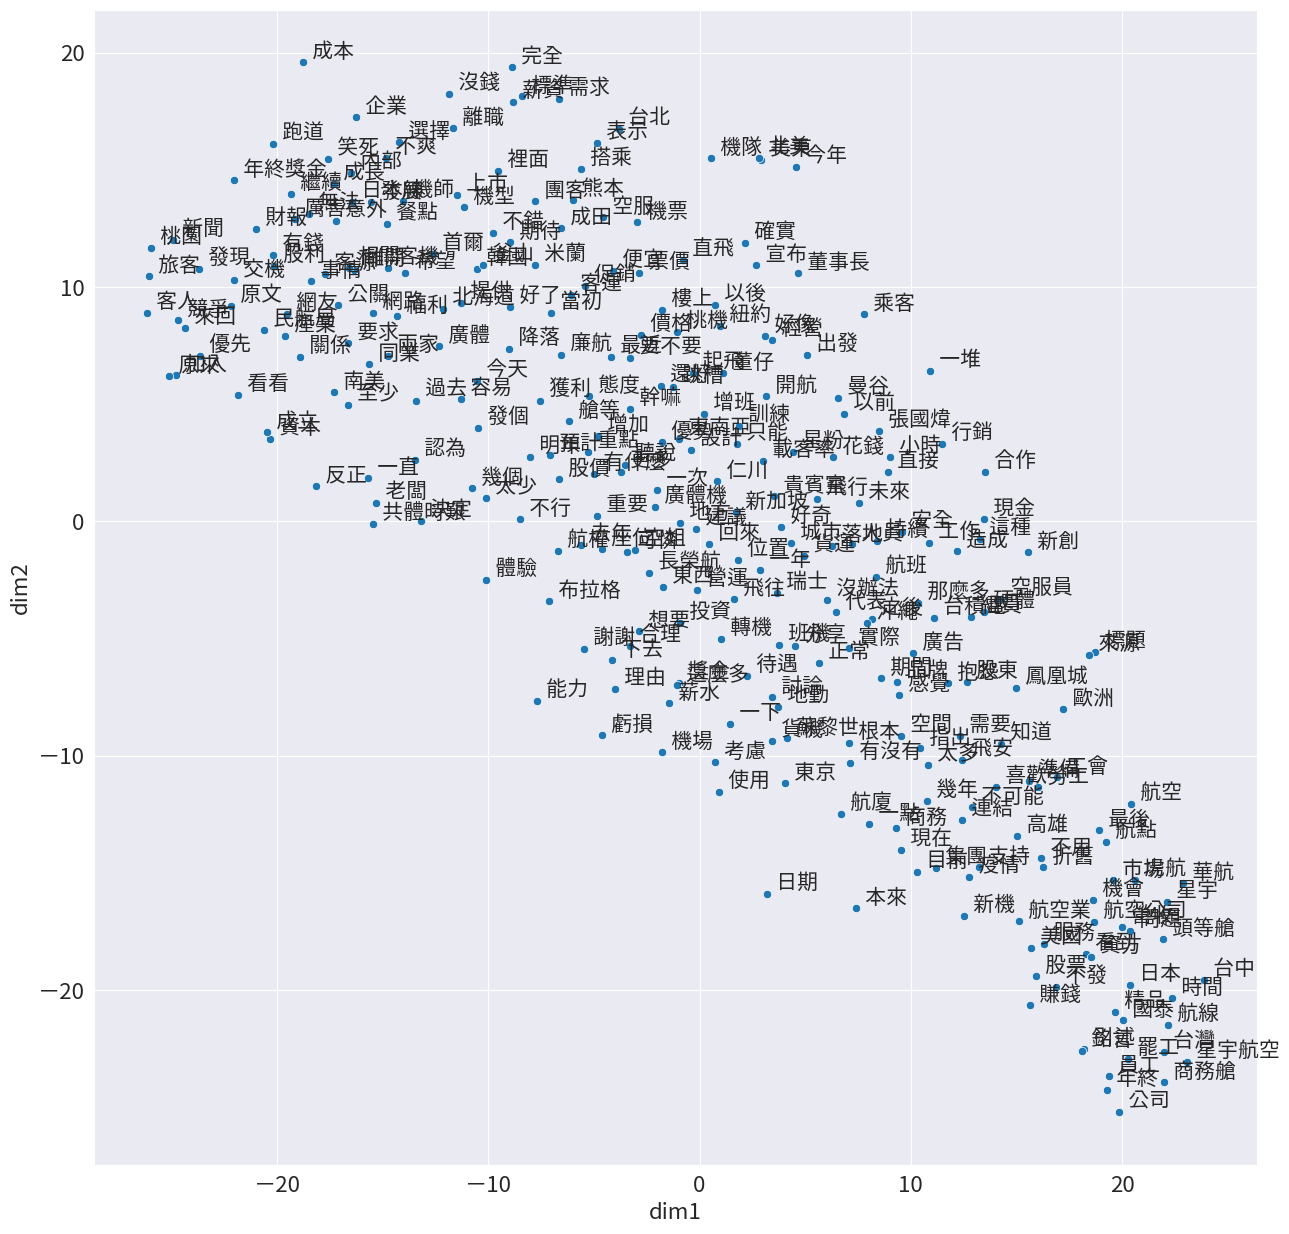

In [70]:
plotScatter(word_df)

3D 散狀圖

In [71]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' )
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(300, 3)


將字分群

In [72]:
!pip install scikit-learn-extra

In [73]:
# kmeans分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result


In [74]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

### Transformers Embeddings

#### 使用 Sentence-Transformer 套件   
參考資料：https://www.sbert.net/index.html

In [ ]:
!pip install -U sentence-transformers

In [75]:
from sentence_transformers import SentenceTransformer, models, util

C:\Users\User\AppData\Local\Temp\ipykernel_33724\593637398.py:1: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import SentenceTransformer, models, util


#### 小模型，以BERT為範例

因為後續在查看結果時會一直使用到此程式碼，所以包成function以便之後使用。

In [76]:
def get_result_df(sentences, cosine_scores):

  result = []
  for i in range(len(sentences)):
      for j in range(i+1, len(sentences)):
          result.append([sentences[i], sentences[j], cosine_scores[i][j].item()])

  result_df = pd.DataFrame(result, columns=["sentence1", "sentence2", "score"])
  result_df = result_df.sort_values("score", ascending = False)

  return result_df

A接下來將以針對中文 BERT 模型做範例。    
中文 bert-base-chinese

In [77]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})


# 範例句子 
sentences = [
    "星宇航空的服務真的很棒",
    "這家航空公司的飛機餐很好吃",
    "我不喜歡這次的飛行體驗"
]

# 使用 encode() 對資料做embedding
embeddings_ch = bert_ch.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_ch, embeddings_ch)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,sentence1,sentence2,score
0,星宇航空的服務真的很棒,這家航空公司的飛機餐很好吃,0.837406
2,這家航空公司的飛機餐很好吃,我不喜歡這次的飛行體驗,0.786229
1,星宇航空的服務真的很棒,我不喜歡這次的飛行體驗,0.785201


針對以上使用 `bert-base-chinese` 產出的相似度分數普遍偏高（約 **0.78 - 0.83**）且區別度不足的現象，分析如下：

1. 為什麼分數集中在 0.78 ~ 0.83 之間？

* 字面重疊度高 ：
    這三個句子共享了強烈的「航空語境」（例如：*航空公司、飛行、服務、體驗*）。對於原生的 BERT 模型而言，它會捕捉到這些詞彙的高度共現性，因此在向量空間中認為這些句子的主題極其接近。
* 缺乏對比訓練 ：
    `bert-base-chinese` 最初的訓練目標是「遮罩語言模型 (MLM)」與「下一句預測 (NSP)」，即預測填空。它並非專門為了區分「正面」與「負面」情感而設計。在模型看來，「服務很棒」和「不喜歡體驗」都屬於「描述飛行感受」的範疇，因此向量距離非常接近。
* 模型侷限：非等向性 ：
    原生 BERT 產出的向量空間通常會呈現錐形分佈，導致所有句子的向量都擠在一個狹小的區域。這種「非等向性」問題會使得即使語義完全相反的句子，其餘弦相似度分數依然維持在高位（如 0.78 以上）。


 2. 數值代表的具體含義

* **0.83 (服務很棒 vs 飛機餐很好吃)**：
    這兩句皆為「正面評價」，且主題皆與航空服務高度相關，因此在空間中距離最近，分數最高。
* **0.78 (正面讚美 vs 負面體驗)**：
    雖然語義上一個是讚美、一個是不喜歡，但由於兩者討論的客體都是「航空體驗」，在基礎模型未經細節微調的情況下，仍會給予極高的相似度評價。


上面課堂中用的模型 結果出來「正評」跟「負評」的分數會太過接近 (0.78-0.83) 故換成以下這個模型  

In [78]:
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
bert_ch = SentenceTransformer(model_name)

# 範例句子 
sentences = [
    "星宇航空的服務真的很棒",
    "這家航空公司的飛機餐很好吃",
    "我不喜歡這次的飛行體驗"
]

# 使用 encode() 對資料做embedding
embeddings_ch = bert_ch.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_ch, embeddings_ch)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\User\anaconda3\envs\sma2026\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,sentence1,sentence2,score
0,星宇航空的服務真的很棒,這家航空公司的飛機餐很好吃,0.541188
2,這家航空公司的飛機餐很好吃,我不喜歡這次的飛行體驗,0.410714
1,星宇航空的服務真的很棒,我不喜歡這次的飛行體驗,0.302536


以上語義相似度分數結果分析

1. 分數高 (0.54) = 語境與情緒接近
* **分析**：「服務棒」與「飛機餐好吃」雖然描述的對象不同，但兩者皆為**正面評價**且都圍繞著**航空體驗**。
* **意義**：模型認為這兩句話在向量空間中的「方向」比較一致，具備較強的關聯性。

2. 分數中 (0.41) = 主題相關但情緒不同
* **分析**：「飛機餐好吃」與「不喜歡飛行體驗」雖然主題都是航空，但存在一正一負的情緒差異。
* **意義**：模型察覺到情緒上的拉伸（情緒位移），因此分數明顯比純粹正面的組合還要低。

3. 分數低 (0.30) = 語義衝突最明顯
* **分析**：「服務真的很棒」與「我不喜歡這次體驗」在語義上是完全相反的（極好 vs 不滿）。
* **意義**：這兩句話在向量空間中的距離最遠，代表模型成功識別出它們是語義衝突的對立面。    

### 使用embedding做NLP任務

#### 相似文件

In [79]:
df_similar = origin_data[['system_id','artTitle', 'artContent']]
df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

C:\Users\User\AppData\Local\Temp\ipykernel_33724\852741673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))


,system_id,artTitle,artContent
0,0,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...
1,1,[問題] 星宇 華航 新加坡 航空選擇,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊
2,2,[問題] 星宇 華航 新加坡 航空選擇,星宇你應該是看到只能托運一件的我最近也有注意到
3,3,[問題] 星宇 華航 新加坡 航空選擇,金城武都選長榮你參考
4,4,[問題] 星宇 華航 新加坡 航空選擇,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到


使用 bert-base-chinese 做示範

In [80]:
# 中文 bert-base-chinese
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_ch = SentenceTransformer('google-bert/bert-base-chinese', device=device)

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0

取得整個文集的 embeddings

In [81]:
corpus_embeddings = bert_ch.encode(
    df_similar['artContent'].tolist(),
    convert_to_tensor=True,
    batch_size=32
)

In [82]:
query_num = 6 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 5


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [問題] 星宇 華航 新加坡 航空選擇

 資料集中前五相似的文章:
[問題] 星宇 華航 新加坡 航空選擇 (Score: 1.0000)
[問題] 星宇 華航 新加坡 航空選擇 (Score: 0.9244)
Re: [新聞] 星宇宣布年終1個月、調薪3%　員工怨太少 (Score: 0.9226)
Re: [情報] 星宇航空2026/03/30開航台中-東京(成田) (Score: 0.9161)
[情報] 星宇台中成田4/15起日日飛、熊本7/11起增班 (Score: 0.9079)






In [83]:
query_num = 30

top_k = 5

query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [問題] 星宇 華航 新加坡 航空選擇

 資料集中前五相似的文章:
[問題] 星宇 華航 新加坡 航空選擇 (Score: 1.0000)
[情報] 2646 星宇航空 114年EPS 、股利 (Score: 0.8555)
[情報] 星宇找蔡依林代言「重返布拉格廣場」 (Score: 0.8489)
Re: [新聞] 星宇宣布年終1個月、調薪3%　員工怨太少 (Score: 0.8373)
Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了 (Score: 0.8367)






### 分類任務
使用bert-base-chinese模型對新聞資料集做embeddings，接著訓練分類器。（參考week7程式碼）


In [84]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [85]:
from sentence_transformers import SentenceTransformer, models, util

In [86]:
# 中文 bert-base-chinese
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_ch = SentenceTransformer('google-bert/bert-base-chinese', device=device)

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0

In [87]:
udn = pd.read_csv("raw_data/starlux_dataset.csv")
udn.head(3)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到


In [88]:
# 過濾 nan 的資料
udn = udn.dropna(subset=['artTitle'])
udn = udn.dropna(subset=['artContent'])
# 移除網址格式
udn["artContent"] = udn.artContent.apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
udn["artTitle"] = udn["artTitle"].apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
# 只留下中文字
udn["artContent"] = udn.artContent.apply(
    lambda x: re.sub("[^一-龥]+", "", x)
)
udn["artTitle"] = udn["artTitle"].apply(
    lambda x: re.sub("[^一-龥]+", "", x)
)

# 留下 content
udn["content"] = udn["artTitle"] + udn["artContent"]
udn.head()


,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,content
0,0,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,unixxxx,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,問題星宇華航新加坡航空選擇請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明...
1,1,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,Steinadler,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,問題星宇華航新加坡航空選擇這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,kyuudonut,星宇你應該是看到只能托運一件的我最近也有注意到,問題星宇華航新加坡航空選擇星宇你應該是看到只能托運一件的我最近也有注意到
3,3,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:54,comment,susan06374,金城武都選長榮你參考,問題星宇華航新加坡航空選擇金城武都選長榮你參考
4,4,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 17:09,comment,MTBF,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到,問題星宇華航新加坡航空選擇非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到


In [89]:
udn["embeddings"] = list(bert_ch.encode(udn["content"].tolist(), batch_size=32, show_progress_bar=True))
udn.head(3)

Batches:   0%|          | 0/128 [00:00<?, ?it/s]

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent,content,embeddings
0,0,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,unixxxx,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,問題星宇華航新加坡航空選擇請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明...,"[0.5114859, -0.10145422, -0.36615786, 0.317435..."
1,1,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,Steinadler,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,問題星宇華航新加坡航空選擇這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,"[0.5504574, 0.059388656, -0.20292377, 0.498975..."
2,2,Aviation,問題星宇華航新加坡航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,kyuudonut,星宇你應該是看到只能托運一件的我最近也有注意到,問題星宇華航新加坡航空選擇星宇你應該是看到只能托運一件的我最近也有注意到,"[0.3342209, -0.25002033, 0.0064802733, 0.13993..."


In [90]:
import numpy as np
from ast import literal_eval

In [91]:
data = udn.copy()

X = np.vstack(data["embeddings"].values)
y = data["board"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

print(X_train.shape, y_train.shape)


(2858, 768) (2858,)


In [92]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
clf

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [93]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
print(y_pred[:10])

['Stock' 'Aviation' 'Aviation' 'Stock' 'Aviation' 'Aviation' 'Stock'
 'Aviation' 'Aviation' 'Stock']


In [94]:
from sklearn.metrics import classification_report

In [95]:
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Aviation       0.98      0.99      0.99       781
       Stock       0.98      0.97      0.98       444

    accuracy                           0.98      1225
   macro avg       0.98      0.98      0.98      1225
weighted avg       0.98      0.98      0.98      1225



---
## 資料集實作任務 — 使用 Embedding 做 NLP 任務

### 任務一：找相似文件（文章）

利用 `paraphrase-multilingual-MiniLM-L12-v2` 多語言 Sentence-BERT 取得每篇文章的 embedding，以餘弦相似度找出最相關的文章。

In [96]:
import pandas as pd
import re
import torch
from sentence_transformers import SentenceTransformer, util

# 讀入資料並前處理
df_sim = pd.read_csv('raw_data/starlux_dataset.csv')
df_sim = df_sim.dropna(subset=['artTitle', 'artContent']).reset_index(drop=True)

def clean_text(text):
    return re.sub('[^一-鿿]+', '', str(text))

df_sim['text_clean'] = (
    df_sim['artTitle'].apply(clean_text) + df_sim['artContent'].apply(clean_text)
)
df_sim = df_sim[df_sim['text_clean'].str.len() > 10].reset_index(drop=True)

print(f"共 {len(df_sim)} 篇文章，類別分布：")
print(df_sim['board'].value_counts())

# 載入多語言 Sentence-BERT，對全部文章做 embedding
sim_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("\n正在對所有文章做 embedding，請稍候...")
corpus_embeddings = sim_model.encode(
    df_sim['text_clean'].tolist(),
    convert_to_tensor=True,
    batch_size=32,
    show_progress_bar=True
)
print(f"Embedding shape: {corpus_embeddings.shape}")

共 4066 篇文章，類別分布：
board
Aviation    2557
Stock       1509
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


正在對所有文章做 embedding，請稍候...


Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Embedding shape: torch.Size([4066, 384])


In [97]:
def find_similar_articles(query_idx, top_k=5):
    """輸入文章 index，顯示前 top_k 篇最相似文章"""
    query_emb = corpus_embeddings[query_idx]
    cos_scores = util.cos_sim(query_emb, corpus_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k + 1)  # +1 排除自身

    title_q = df_sim['artTitle'].iloc[query_idx]
    board_q = df_sim['board'].iloc[query_idx]
    print(f"Query（index={query_idx}）[{board_q}]：【{title_q}】")
    print("=" * 70)

    count = 0
    for score, idx in zip(top_results[0], top_results[1]):
        if idx.item() == query_idx:
            continue
        title = df_sim['artTitle'].iloc[idx.item()]
        board = df_sim['board'].iloc[idx.item()]
        print(f"  Top {count+1}. [{board}]【{title}】  相似度：{score.item():.4f}")
        count += 1
        if count >= top_k:
            break
    print()

# 以三篇不同的文章示範
for qidx in [0, 50, 100]:
    find_similar_articles(qidx, top_k=5)

Query（index=0）[Aviation]：【[問題] 星宇 華航 新加坡 航空選擇】
  Top 1. [Aviation]【[問題] 星宇 華航 新加坡 航空選擇】  相似度：0.8358
  Top 2. [Aviation]【[問題] 星宇 華航 新加坡 航空選擇】  相似度：0.8249
  Top 3. [Aviation]【[問題] 星宇 華航 新加坡 航空選擇】  相似度：0.8175
  Top 4. [Aviation]【[問題] 星宇 華航 新加坡 航空選擇】  相似度：0.7958
  Top 5. [Aviation]【[問題] 星宇 華航 新加坡 航空選擇】  相似度：0.7790

Query（index=50）[Aviation]：【[閒聊] 星宇航空找金城武拍廣告可以洗白嗎？】
  Top 1. [Aviation]【[閒聊] 星宇航空找金城武拍廣告可以洗白嗎？】  相似度：0.9654
  Top 2. [Aviation]【[閒聊] 星宇航空找金城武拍廣告可以洗白嗎？】  相似度：0.9580
  Top 3. [Aviation]【[閒聊] 星宇航空找金城武拍廣告可以洗白嗎？】  相似度：0.9516
  Top 4. [Aviation]【[閒聊] 星宇航空找金城武拍廣告可以洗白嗎？】  相似度：0.9394
  Top 5. [Aviation]【[閒聊] 星宇航空找金城武拍廣告可以洗白嗎？】  相似度：0.9218

Query（index=100）[Aviation]：【Re: [情報] 星宇航空增租A321neo/減租A330neo】
  Top 1. [Aviation]【Re: [情報] 星宇航空增租A321neo/減租A330neo】  相似度：0.8263
  Top 2. [Aviation]【Re: [情報] 星宇航空增租A321neo/減租A330neo】  相似度：0.8214
  Top 3. [Aviation]【Re: [情報] 星宇航空增租A321neo/減租A330neo】  相似度：0.8161
  Top 4. [Aviation]【Re: [情報] 星宇航空增租A321neo/減租A330neo】  相似度：0.8121
  Top 5. [Aviation]【Re: [情報] 

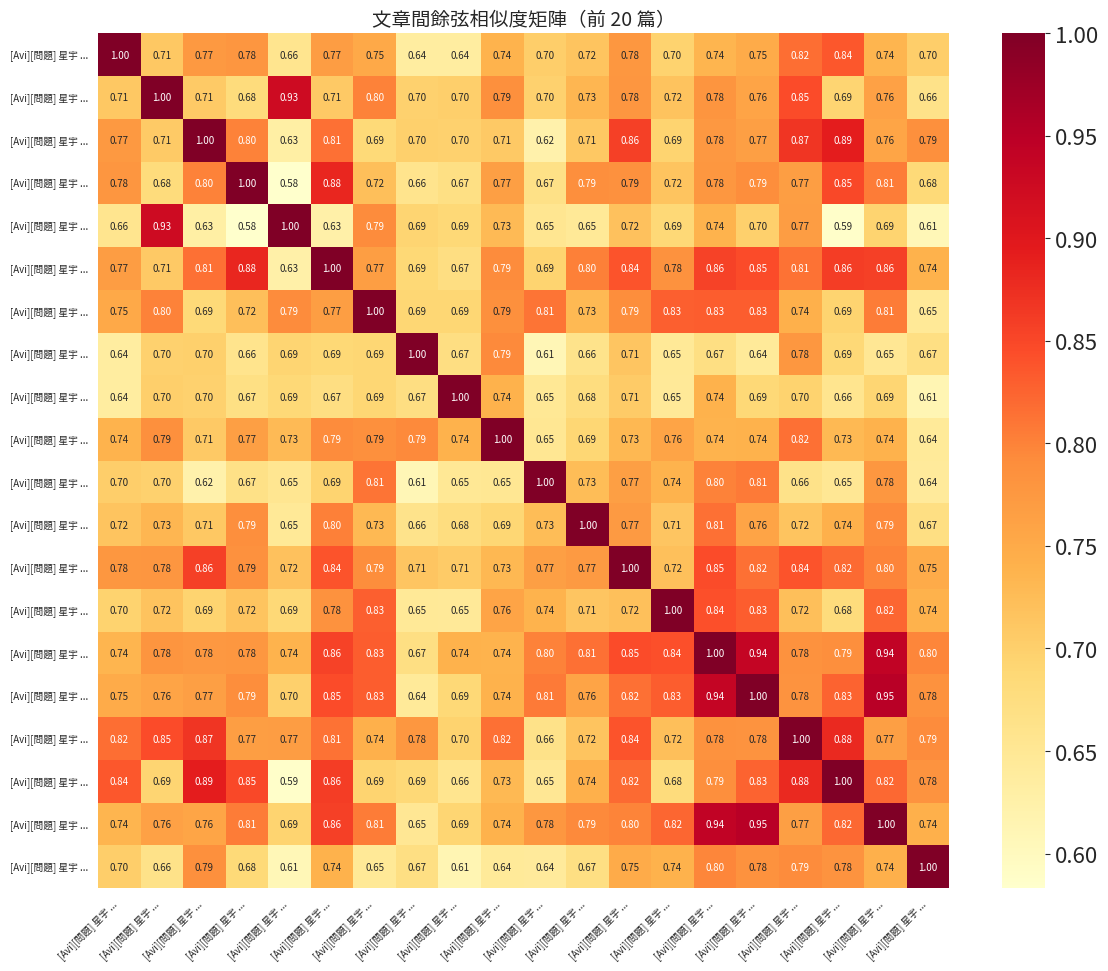

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import fontManager

fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']

# 取前 20 篇文章，計算兩兩相似度並畫 heatmap
sample_idx = list(range(20))
sample_labels = [
    f"[{df_sim['board'].iloc[i][:3]}]{df_sim['artTitle'].iloc[i][:8]}..."
    for i in sample_idx
]
sample_embs = corpus_embeddings[sample_idx]
sim_matrix = util.cos_sim(sample_embs, sample_embs).cpu().numpy()

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=sample_labels, yticklabels=sample_labels,
    annot_kws={'size': 7}
)
plt.title('文章間餘弦相似度矩陣（前 20 篇）', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

### 任務二：文件分類任務

以文章 embedding 作為特徵，訓練 **Logistic Regression** 分類器，預測文章屬於 **Aviation**（航空板）還是 **Stock**（股票板）。

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 用 embedding 作為特徵，board 作為標籤
X = corpus_embeddings.cpu().numpy()
y = df_sim['board']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"訓練集: {len(X_train)} 筆  |  測試集: {len(X_test)} 筆\n")

# 訓練 Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("=== Logistic Regression 分類結果 ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

訓練集: 2846 筆  |  測試集: 1220 筆

=== Logistic Regression 分類結果 ===

Accuracy: 0.9500

              precision    recall  f1-score   support

    Aviation       0.96      0.96      0.96       767
       Stock       0.93      0.93      0.93       453

    accuracy                           0.95      1220
   macro avg       0.95      0.95      0.95      1220
weighted avg       0.95      0.95      0.95      1220



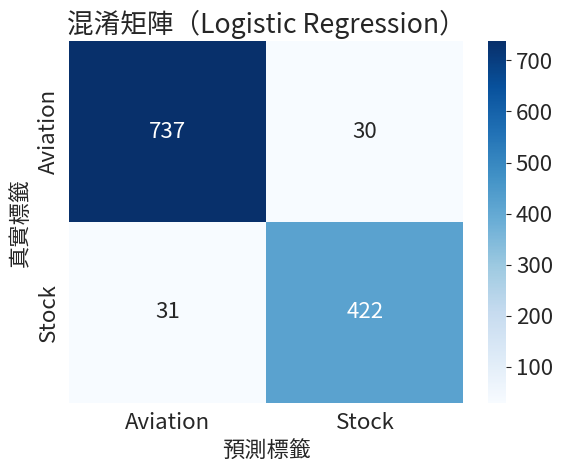

In [100]:
# 混淆矩陣視覺化
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes
)
plt.title('混淆矩陣（Logistic Regression）')
plt.ylabel('真實標籤')
plt.xlabel('預測標籤')
plt.tight_layout()
plt.show()

# 第十二週：BERT (Encoder-only-model)
---

本週「BERT (Encoder-only-model)」，主要會介紹不同 BERT 相關下游任務的程式碼應用，學習目標著重在如何使用 BERT 相關資源（例如網路上別人訓練好的 BERT 模型）來達成 Token classification、Sequence classification 以及 Text Clustering 等等相關文字處理任務。

### 大綱：
1. 套件介紹
2. 資料前處理
3. Token classification<br>
  3.1 NER<br>
4. Sequence classification<br>
  4.1 Sentiment Classification<br>
5. Text Clustering<br>
  5.1 套用中文資料<br>
  5.2 使用Representation方法去微調主題表示



### 1. 套件

In [1]:
# import os

# from google.colab import drive
# drive.mount('/content/drive')

# os.chdir('/content/drive/MyDrive/') # 請將這行修改為自己的 google drive 主目錄

# 下載所需檔案(我們的GitHub檔案，包含dict等)
# !git clone https://github.com/wooooodfire/SMA_G2_PRJ1.git
# !cd SMA_G2_PRJ1
# os.listdir() # 確認目錄內容

In [2]:
# 安裝package
!pip install jieba
!pip install sentence_transformers
!pip install ckip_transformers
!pip install bertopic

In [101]:
import pandas as pd
import re
import numpy as np
from collections import defaultdict
import multiprocessing
import jieba
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager
import ast

# 設定字體
fontManager.addfont("./raw_data/SourceHanSansTW-Regular.otf")
plt.rcParams['font.family'] = 'Source Han Sans TW'
plt.rcParams['font.sans-serif'] = ['Source Han Sans TW']
plt.rcParams['axes.unicode_minus'] = False


**Transformers 和 Sentence-transformers （使用 huggingface 模型）**

In [102]:
from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker

**BERTopic套件**

In [103]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

In [104]:
import torch
print(torch.cuda.is_available())

True


### 2. 資料前處理

In [105]:
# 讀入starlux資料集
origin_data = pd.read_csv('./raw_data/starlux_dataset.csv')

In [106]:
# 同義詞
SYNONYM_MAP = {
    '台灣人': '台灣', '台中人': '台灣', '台北人': '台灣', '台籍': '台灣', '中部人': '台灣',
    '日式': '日本', '日籍': '日本',
    '中華航空': '華航', '中航': '華航',
    '美國人': '美國', '美籍': '美國',
    '韓籍': '韓國', '韓國人': '韓國',
}

SPECIAL_SYMBOLS = (
    r'[.＂<>:《》+\-=#$%&()*@＃＄％＆＇\(\)\[\]\{\}（）＊＋－／：'
    r'＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿'
    r'–—一\'\'‛""„‟…‧﹏★→─]+'
)
SEG_TOKENS = (";", "；", "！", "!", "？", "?", "。", ",", "，")

URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')


def clean_and_segment(article: str, keep_digits: bool = True, keep_alphabets: bool = True) -> list[str]:
    if not isinstance(article, str):
        article = str(article)

    # 1. 移除網址
    article = URL_PATTERN.sub('', article)

    # 2. 統一換行符號（含字面上的 \\n）
    article = re.sub(r'\\n', '\n', article)
    article = re.sub(r'[\r\t]+', '', article)

    # 3. 依換行切段落，過濾空白段落
    paragraphs = [p for p in article.split('\n') if re.sub(r'\s+', '', p)]

    sentences = []
    for para in paragraphs:
        # 4. 同義詞替換（斷句前先統一用詞）
        for old, new in SYNONYM_MAP.items():
            para = para.replace(old, new)

        # 5. 選擇性保留數字 / 英文
        if not keep_digits:
            para = re.sub(r'\d*\.?\d+', '', para)
        if not keep_alphabets:
            para = re.sub(r'[a-zA-Z]+', '', para)

        # 6. 移除空格與特殊符號
        para = re.sub(r'\s+', '', para)
        para = re.sub(SPECIAL_SYMBOLS, '', para)

        # 7. 斷句
        seg_pattern = '|'.join(map(re.escape, SEG_TOKENS))
        segs = re.split(seg_pattern, para)

        # 8. 只保留中文字（對齊下方的 re.sub('[^\u4e00-\u9fff]+', '', x)）
        segs = [re.sub(r'[^\u4e00-\u9fff]', '', s) for s in segs]

        # 9. 過濾：長度 > 1 且含中文
        segs = [s for s in segs
                if len(s.strip()) > 1 and re.search(r'[\u4e00-\u9fff]', s)]
        sentences.extend(segs)

    return sentences


# ── DataFrame 處理 ──────────────────────────────────────────────────────
# 去除一些不需要的欄位
metaData = origin_data.drop(['artPoster'], axis=1)

# 將 artDate 轉換為 datetime 格式，並只保留日期部分
metaData["artDate"] = pd.to_datetime(metaData["artDate"]).dt.date

# 去除文章內容為空值的筆數
metaData.dropna(subset=['artContent'], axis=0, how='any', inplace=True)

# 清理 & 斷句（每個 cell → 句子 list）
metaData['sentence'] = metaData['artContent'].apply(clean_and_segment)

# 展開為每句一列
metaData = metaData.explode('sentence').reset_index(drop=True)

# 過濾斷句後的空值或空字串
metaData = metaData[metaData['sentence'].str.len() > 0].reset_index(drop=True)

metaData.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artContent,sentence
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,星宇星加坡長榮會怎麼選呢
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的不明白怎麼差那麼多
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,但是如果選星宇累計的里程和星加坡長榮應該是分開的
4,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話
5,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢
6,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,還是都用班機時刻選
7,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問大家會怎麼選
8,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,感謝
9,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026-03-14,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的


In [107]:
print("=" * 40)
print(f"總句數：{len(metaData)}")
print(f"總文章數：{metaData['system_id'].nunique()}")
print(f"日期範圍：{metaData['artDate'].min()} ～ {metaData['artDate'].max()}")
print(f"句子平均長度：{metaData['sentence'].str.len().mean():.1f} 字")
print(f"句子最短／最長：{metaData['sentence'].str.len().min()} ／ {metaData['sentence'].str.len().max()} 字")
print("=" * 40)
metaData.info()

總句數：10370
總文章數：4008
日期範圍：2025-12-06 ～ 2026-03-17
句子平均長度：12.1 字
句子最短／最長：2 ／ 340 字
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10370 entries, 0 to 10369
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   system_id   10370 non-null  int64 
 1   board       10370 non-null  object
 2   artTitle    10370 non-null  object
 3   artUrl      10370 non-null  object
 4   artDate     10370 non-null  object
 5   rowType     10370 non-null  object
 6   artContent  10370 non-null  object
 7   sentence    10370 non-null  object
dtypes: int64(1), object(7)
memory usage: 648.3+ KB


## 3. Token classification

### NER
使用 Huggingface 上面已經針對 NER 任務 finetune 好的 BERT 模型來實作<br>
Huggingface 的模型列表：https://huggingface.co/models?sort=trending

如果找不到自己適用的模型的話，也可以透過 fine-tune 來建立自己的模型。<br>
本課程因為時間與資源因素，僅針對「如何使用網路上他人 fine-tune 好的模型」進行程式碼示範，不提供 fine-tune 程式碼範例。<br>
如有需要，可參考 Huggingface 相關教學文章：[Fine-tune a pretrained model](https://huggingface.co/docs/transformers/training)

#### 3.1 中文 NER：<br>

**將CKIP套用到我們先前處理好的資料集**

使用 CKIP 開發的 NLP 套件：ckip_transformers<br>
- 使用的 WS 模型：https://huggingface.co/ckiplab/bert-base-chinese-ws<br>
- 使用的 POS 模型：https://huggingface.co/ckiplab/bert-base-chinese-pos<br>
- 使用的 NER 模型：https://huggingface.co/ckiplab/bert-base-chinese-ner

In [10]:
# # 初始化 ckip 工具 device=0 使用GPU ｜ device=-1 使用CPU（速度會很慢）
# # Mac使用者可以設定 device=torch.device("mps") 使用GPU
# ws_driver  = CkipWordSegmenter(model_name="ckiplab/bert-base-chinese-ws", device=0) # Word Segmenter斷詞
# pos_driver = CkipPosTagger(model_name="ckiplab/bert-base-chinese-pos", device=0) # POS tagger 詞性標記
# ner_driver = CkipNerChunker(model_name="ckiplab/bert-base-chinese-ner", device=0) # NER識別

In [11]:
# 跑模型
# text = metaData['sentence'].tolist()

# # 執行處理
# ws = ws_driver(text) # 斷詞
# pos = pos_driver(ws) # POS
# ner = ner_driver(text) # NER

# # 將斷詞以及 pos 結果合在一起顯示
# def pack_ws_pos_sentece(sentence_ws, sentence_pos):
#     assert len(sentence_ws) == len(sentence_pos) # 確認斷詞和POS的長度相同
#     res = []
#     for word_ws, word_pos in zip(sentence_ws, sentence_pos):
#         res.append(f"{word_ws}({word_pos})") # 合併在一起
#     return "\u3000".join(res)

# sentences, packed_sentences, entities = [], [], []

# # 儲存結果
# for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
#     sentences.append(sentence)
#     packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
#     clean_entities = [{'word': entity.word, 'ner': entity.ner} for entity in sentence_ner]
#     entities.append(clean_entities)

# # 將結果存在一個 dataframe 中
# ner_results = pd.DataFrame({
#    'sentence': sentences,
#    'packed_sentence': packed_sentences,
#    'entities': entities
# })

# ner_results.head(10)
# # 備份
# ner_results.to_csv('raw_data/ckip_transformers_base.csv', index=False)


In [108]:
# # 讀取已跑好的資料

# 讀取
ner_results = pd.read_csv('raw_data/ckip_transformers_base.csv')

# entities 欄位從字串還原為 list of dict
ner_results['entities'] = ner_results['entities'].apply(ast.literal_eval)

In [109]:
def plot_top10(df, title, color='steelblue'):
    """
    df: 兩欄 DataFrame，第一欄為標籤，第二欄為數量
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    labels = df.iloc[:, 0].astype(str)
    counts = df.iloc[:, 1]

    bars = ax.barh(labels[::-1], counts[::-1], color=color)  # 由高到低排列

    # 在每個 bar 右側標上數值
    for bar, count in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                str(count), va='center', fontsize=10)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Count', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

   NER_Type  Count
0       GPE   1794
1       ORG   1283
2      DATE    829
3    PERSON    454
4       LOC    346
5  CARDINAL    328
6       FAC    127
7      TIME    115
8   ORDINAL     98
9      NORP     74


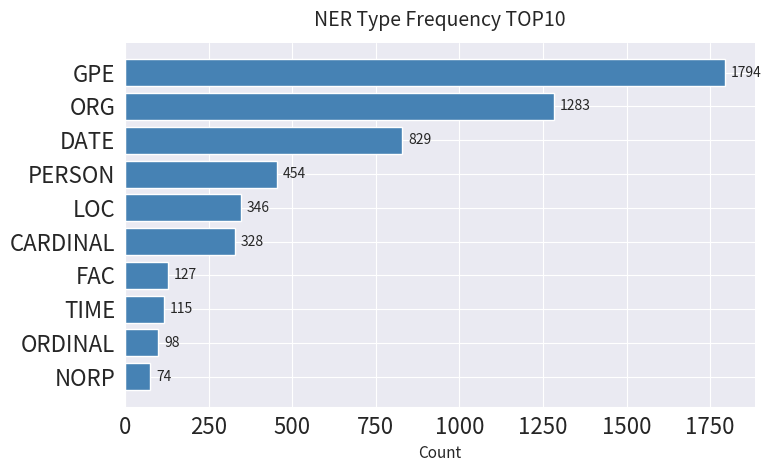

In [110]:
# 1. NER Frequency（ TOP10）
from collections import Counter

# 攤平所有 entity，取出 ner 類型
all_ner_types = [
    entity['ner']
    for entities in ner_results['entities']
    for entity in entities
]

ner_freq = pd.DataFrame(
    Counter(all_ner_types).most_common(10),
    columns=['NER_Type', 'Count']
)
print(ner_freq)
plot_top10(ner_freq, 'NER Type Frequency TOP10', color='steelblue')

=== GPE ===
  Word  Count
0   台中    194
1   台灣    150
2   日本    132
3   高雄     77
4   台北     58
5   美國     44
6   釜山     43
7   成田     41
8   桃園     41
9    台     40


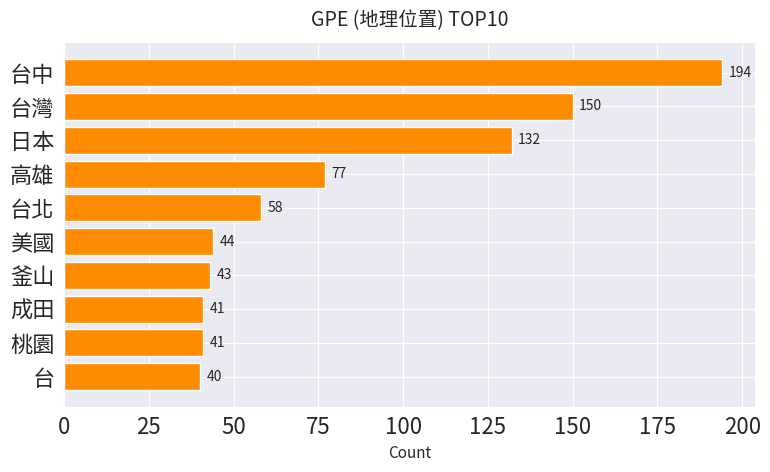

In [111]:
# 2. GPE TOP10
def get_ner_top(ner_results, ner_type, top_n=10):
    words = [
        entity['word']
        for entities in ner_results['entities']
        for entity in entities
        if entity['ner'] == ner_type
    ]
    return pd.DataFrame(
        Counter(words).most_common(top_n),
        columns=['Word', 'Count']
    )

gpe_top10    = get_ner_top(ner_results, 'GPE')

print("=== GPE ===");    print(gpe_top10)

plot_top10(gpe_top10, 'GPE (地理位置) TOP10', color='darkorange')

=== NORP ===
  Word  Count
0   台灣     15
1   日本      8
2  日本人      4
3   台股      4
4   高雄      3
5  高雄人      2
6   歐洲      2
7   澳洲      2
8   亞裔      2
9   台女      2


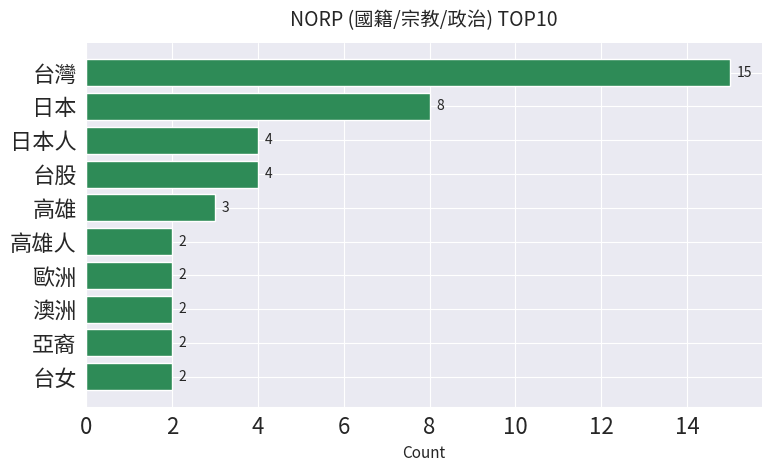

In [112]:
# 3. NORP TOP10
norp_top10   = get_ner_top(ner_results, 'NORP')

print("=== NORP ===");   print(norp_top10)

plot_top10(norp_top10, 'NORP (國籍/宗教/政治) TOP10', color='seagreen')


=== ORG ===
   Word  Count
0    星宇    406
1    華航    209
2  星宇航空    144
3    長榮     66
4    虎航     48
5    日航     33
6    國泰     23
7  長榮華航     23
8   民航局     23
9   台積電     21


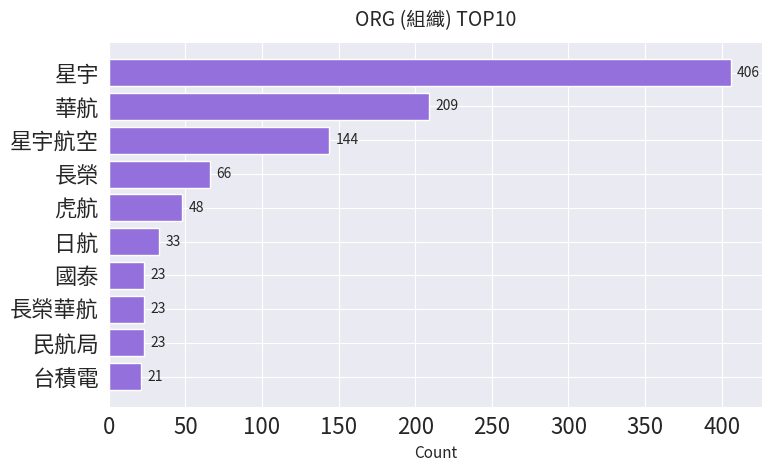

In [113]:
# 4. ORG TOP10
org_top10    = get_ner_top(ner_results, 'ORG')

print("=== ORG ===");    print(org_top10)

plot_top10(org_top10, 'ORG (組織) TOP10', color='mediumpurple')

  Word  Count
0  張國煒     80
1   星宇     39
2  布拉格     29
3   長榮     22
4  陳漢典     15
5  翟健華     12
6  蔡依林     12
7  張榮發     10
8  史努比      9
9  劉允富      5


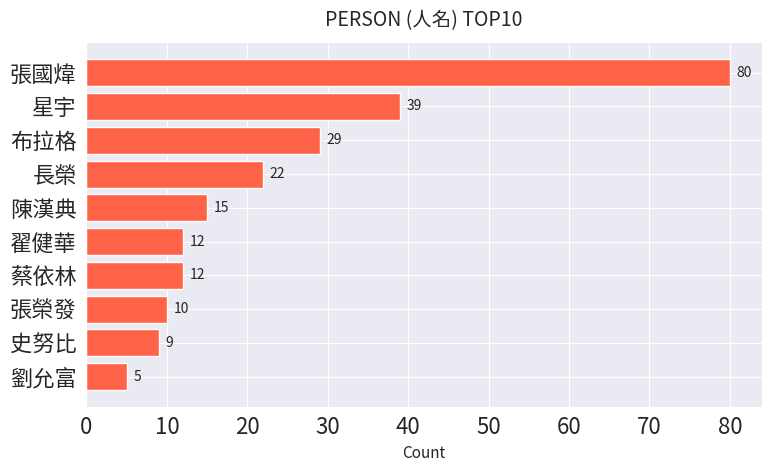

In [114]:
# 5. PERSON TOP10

# 排除清單 & 別稱對照
not_person = []
person_alias = {'Joli': '蔡依林', 'jolin': '蔡依林', 'Jolin': '蔡依林',
                '張': '張國煒', '董仔': '張國煒', 'k董': '張國煒', 'K董': '張國煒', '張董': '張國煒'}

# 抽取 → 排除 → 合併別稱 → 計數
person_top10 = (
    pd.Series([e['word'] for entities in ner_results['entities']
                         for e in entities if e['ner'] == 'PERSON'])
      .pipe(lambda s: s[~s.isin(not_person)])
      .replace(person_alias)
      .value_counts()
      .nlargest(10)
      .reset_index()
      .set_axis(['Word', 'Count'], axis=1)
)

print(person_top10)
plot_top10(person_top10, 'PERSON (人名) TOP10', color='tomato')

  POS_Tag  Count
0      Na  14221
1       D  11815
2      VC   5755
3      VH   5394
4      Nc   4393
5      DE   2934
6      VA   2733
7       P   2635
8      Nf   2181
9       T   2048


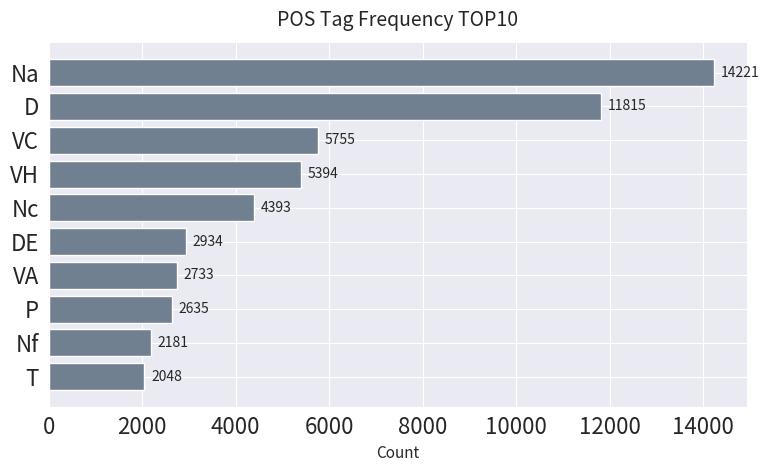

In [115]:
# 6. POS Frequency（所有詞性）
all_pos = []
for packed in ner_results['packed_sentence']:
    # 抓出所有 (POS) 括號內的標籤
    pos_tags = re.findall(r'\((\w+)\)', packed)
    all_pos.extend(pos_tags)

pos_freq = pd.DataFrame(
    Counter(all_pos).most_common(10),
    columns=['POS_Tag', 'Count']
)
print(pos_freq)

plot_top10(pos_freq, 'POS Tag Frequency TOP10', color='slategray')



=== Noun (Nb) ===
  Word  Count
0   星宇    642
1   長榮    245
2  張國煒    156
3   虎航     76
4   國泰     56
5   日航     24
6    阿     24
7  台積電     20
8  史努比     18
9   羽田     17


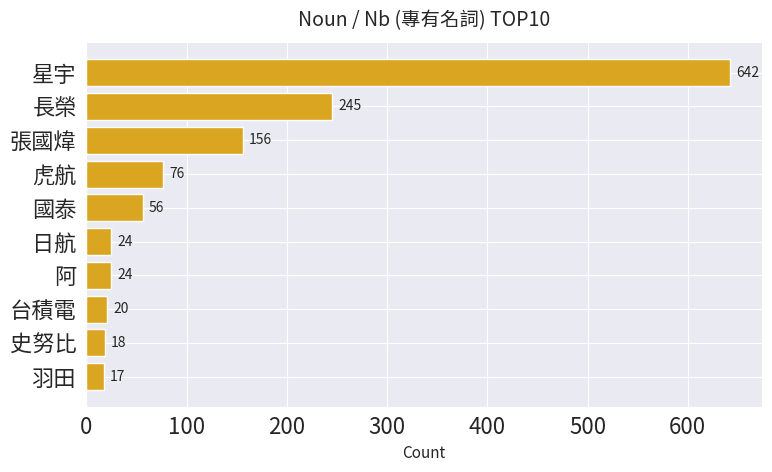

In [116]:
# 7. Noun TOP10

# 排除清單 & 別稱對照（Noun 專用）
not_noun = []  # 有需要排除的詞可以加在這裡
noun_alias = {'星宇航空': '星宇', '董': '張國煒', '董仔': '張國煒'}

def get_pos_words_top(ner_results, pos_prefix, top_n=10,
                      exclude=None, alias=None):
    words = []
    for packed in ner_results['packed_sentence']:
        pairs = re.findall(r'([^\s　]+)\((\w+)\)', packed)
        for word, pos in pairs:
            if pos.startswith(pos_prefix):
                words.append(word)

    return (pd.Series(words)
              .pipe(lambda s: s[~s.isin(exclude)] if exclude else s)
              .replace(alias if alias else {})
              .value_counts()
              .nlargest(top_n)
              .reset_index()
              .set_axis(['Word', 'Count'], axis=1))


# Noun（Nb 或 Na，依需求傳入）
noun_top10 = get_pos_words_top(ner_results, 'Nb', exclude=not_noun, alias=noun_alias)

print("=== Noun (Nb) ==="); print(noun_top10)
plot_top10(noun_top10, 'Noun / Nb (專有名詞) TOP10', color='goldenrod')

=== VC ===
  Word  Count
0   服務     66
1   經營     55
2   加入     42
3   使用     40
4   選擇     38
5   直飛     34
6   新創     32
7   支持     31
8   成立     25
9   投資     25


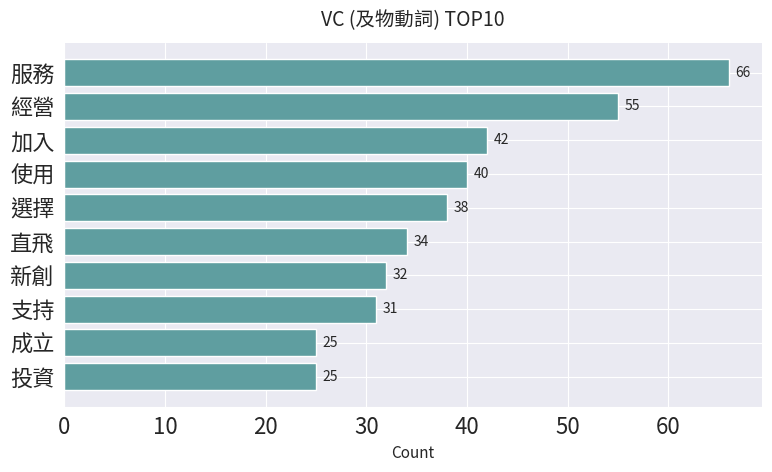

In [117]:
# 8. VC TOP10

def get_pos_words_top(ner_results, pos_prefix, top_n=10,
                      exclude=None, alias=None, min_len=1):
    words = []
    for packed in ner_results['packed_sentence']:
        pairs = re.findall(r'([^\s　]+)\((\w+)\)', packed)
        for word, pos in pairs:
            if pos.startswith(pos_prefix):
                words.append(word)

    return (pd.Series(words)
              .pipe(lambda s: s[s.map(len) >= min_len] if min_len > 1 else s)  # 長度過濾  # 長度過濾
              .pipe(lambda s: s[~s.isin(exclude)] if exclude else s)
              .replace(alias if alias else {})
              .value_counts()
              .nlargest(top_n)
              .reset_index()
              .set_axis(['Word', 'Count'], axis=1))


# VC：過濾長度為 1 的字
vc_top10 = get_pos_words_top(ner_results, 'VC', min_len=2)

print("=== VC ==="); print(vc_top10)
plot_top10(vc_top10, 'VC (及物動詞) TOP10', color='cadetblue')

來試試看用tiny版本

In [22]:
# 跑模型
# # 初始化 ckip 工具 device=0 使用GPU ｜ device=-1 使用CPU（速度會很慢）
# # Mac使用者可以設定 device=torch.device("mps") 使用GPU
# ws_driver  = CkipWordSegmenter(model_name="ckiplab/bert-tiny-chinese-ws", device=0) # Word Segmenter斷詞
# pos_driver = CkipPosTagger(model_name="ckiplab/bert-tiny-chinese-pos", device=0) # POS tagger 詞性標記
# ner_driver = CkipNerChunker(model_name="ckiplab/bert-tiny-chinese-ner", device=0) # NER識別


# # 執行處理
# ws = ws_driver(text) # 斷詞
# pos = pos_driver(ws) # POS
# ner = ner_driver(text) # NER

# sentences, packed_sentences, entities = [], [], []

# # 儲存結果
# for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
#     sentences.append(sentence)
#     packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
#     clean_entities = [{'word': entity.word, 'ner': entity.ner} for entity in sentence_ner]
#     entities.append(clean_entities)

# # 將結果存在一個 dataframe 中
# ner_results = pd.DataFrame({
#    'sentence': sentences,
#    'packed_sentence': packed_sentences,
#    'entities': entities
# })

# ner_results.head(10)
# # 備份
# ner_results.to_csv('raw_data/ckip_transformers_tiny.csv', index=False)

In [23]:
# # 讀取已跑好的資料

# 讀取
ner_results = pd.read_csv('raw_data/ckip_transformers_tiny.csv')

# entities 欄位從字串還原為 list of dict
ner_results['entities'] = ner_results['entities'].apply(ast.literal_eval)

   NER_Type  Count
0       GPE   1794
1       ORG   1283
2      DATE    829
3    PERSON    454
4       LOC    346
5  CARDINAL    328
6       FAC    127
7      TIME    115
8   ORDINAL     98
9      NORP     74


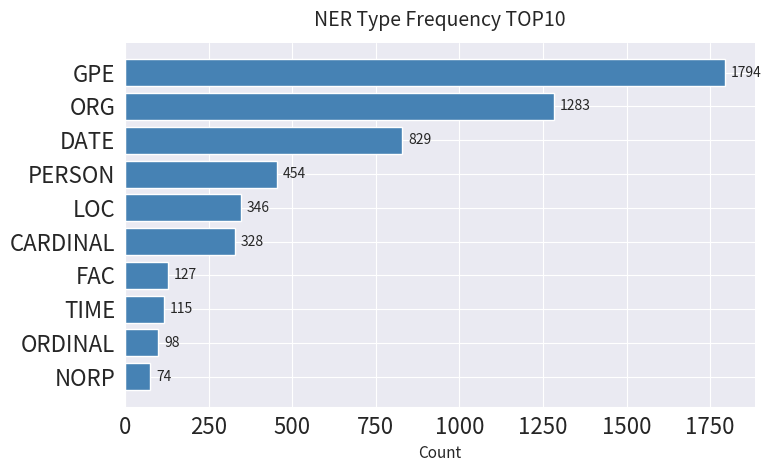

In [118]:
from collections import Counter

# 攤平所有 entity，取出 ner 類型
all_ner_types = [
    entity['ner']
    for entities in ner_results['entities']
    for entity in entities
]

ner_freq = pd.DataFrame(
    Counter(all_ner_types).most_common(10),
    columns=['NER_Type', 'Count']
)
print(ner_freq)
plot_top10(ner_freq, 'NER Type Frequency TOP10', color='steelblue')

=== GPE ===
  Word  Count
0   台中    194
1   台灣    150
2   日本    132
3   高雄     77
4   台北     58
5   美國     44
6   釜山     43
7   成田     41
8   桃園     41
9    台     40


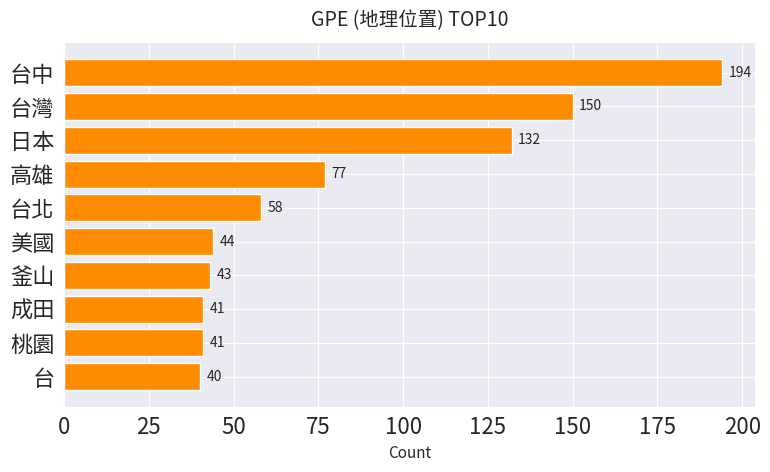

In [119]:
# 2. GPE TOP10
def get_ner_top(ner_results, ner_type, top_n=10):
    words = [
        entity['word']
        for entities in ner_results['entities']
        for entity in entities
        if entity['ner'] == ner_type
    ]
    return pd.DataFrame(
        Counter(words).most_common(top_n),
        columns=['Word', 'Count']
    )

gpe_top10    = get_ner_top(ner_results, 'GPE')

print("=== GPE ===");    print(gpe_top10)

plot_top10(gpe_top10, 'GPE (地理位置) TOP10', color='darkorange')

=== NORP ===
  Word  Count
0   台灣     15
1   日本      8
2  日本人      4
3   台股      4
4   高雄      3
5  高雄人      2
6   歐洲      2
7   澳洲      2
8   亞裔      2
9   台女      2


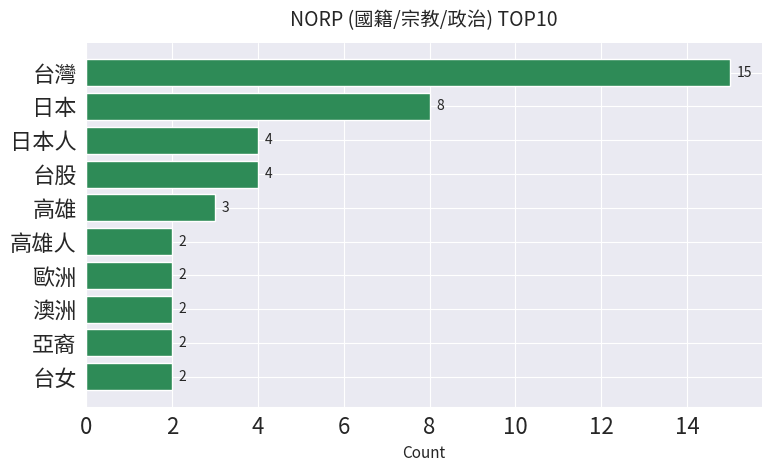

In [120]:
# 3. NORP TOP10
norp_top10   = get_ner_top(ner_results, 'NORP')

print("=== NORP ===");   print(norp_top10)

plot_top10(norp_top10, 'NORP (國籍/宗教/政治) TOP10', color='seagreen')


=== ORG ===
   Word  Count
0    星宇    406
1    華航    209
2  星宇航空    144
3    長榮     66
4    虎航     48
5    日航     33
6    國泰     23
7  長榮華航     23
8   民航局     23
9   台積電     21


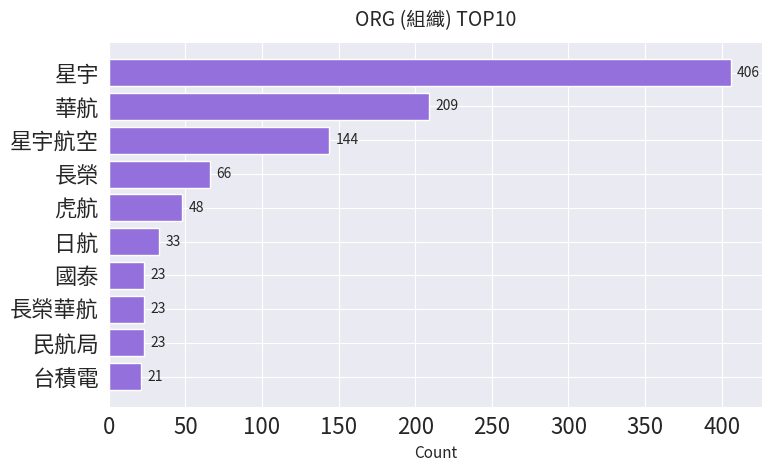

In [121]:
# 4. ORG TOP10
org_top10    = get_ner_top(ner_results, 'ORG')

print("=== ORG ===");    print(org_top10)

plot_top10(org_top10, 'ORG (組織) TOP10', color='mediumpurple')

  Word  Count
0  張國煒     80
1   星宇     39
2  布拉格     29
3   長榮     22
4  陳漢典     15
5  翟健華     12
6  蔡依林     12
7  張榮發     10
8  史努比      9
9  劉允富      5


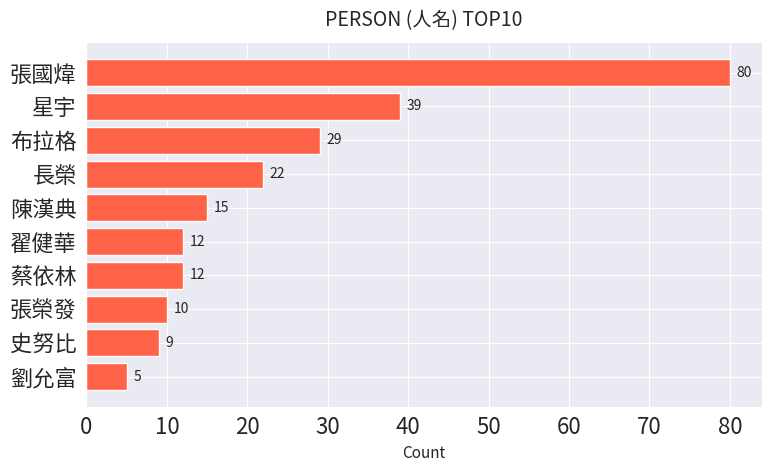

In [122]:
# 5. PERSON TOP10

# 排除清單 & 別稱對照
not_person = []
person_alias = {'Joli': '蔡依林', 'jolin': '蔡依林', 'Jolin': '蔡依林',
                '張': '張國煒', '董仔': '張國煒', 'k董': '張國煒', 'K董': '張國煒', '張董': '張國煒'}

# 抽取 → 排除 → 合併別稱 → 計數
person_top10 = (
    pd.Series([e['word'] for entities in ner_results['entities']
                         for e in entities if e['ner'] == 'PERSON'])
      .pipe(lambda s: s[~s.isin(not_person)])
      .replace(person_alias)
      .value_counts()
      .nlargest(10)
      .reset_index()
      .set_axis(['Word', 'Count'], axis=1)
)

print(person_top10)
plot_top10(person_top10, 'PERSON (人名) TOP10', color='tomato')

  POS_Tag  Count
0      Na  14221
1       D  11815
2      VC   5755
3      VH   5394
4      Nc   4393
5      DE   2934
6      VA   2733
7       P   2635
8      Nf   2181
9       T   2048


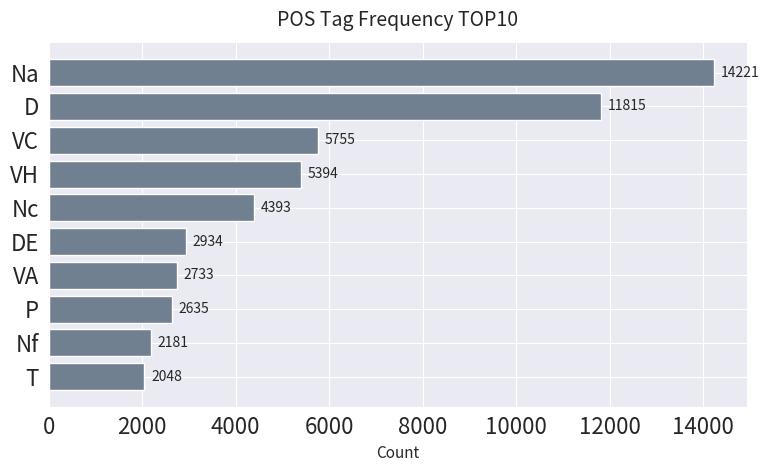

In [123]:
# 6. POS Frequency（所有詞性）
all_pos = []
for packed in ner_results['packed_sentence']:
    # 抓出所有 (POS) 括號內的標籤
    pos_tags = re.findall(r'\((\w+)\)', packed)
    all_pos.extend(pos_tags)

pos_freq = pd.DataFrame(
    Counter(all_pos).most_common(10),
    columns=['POS_Tag', 'Count']
)
print(pos_freq)

plot_top10(pos_freq, 'POS Tag Frequency TOP10', color='slategray')



=== Noun (Nb) ===
  Word  Count
0   星宇    642
1   長榮    245
2  張國煒    156
3   虎航     76
4   國泰     56
5   日航     24
6    阿     24
7  台積電     20
8  史努比     18
9   羽田     17


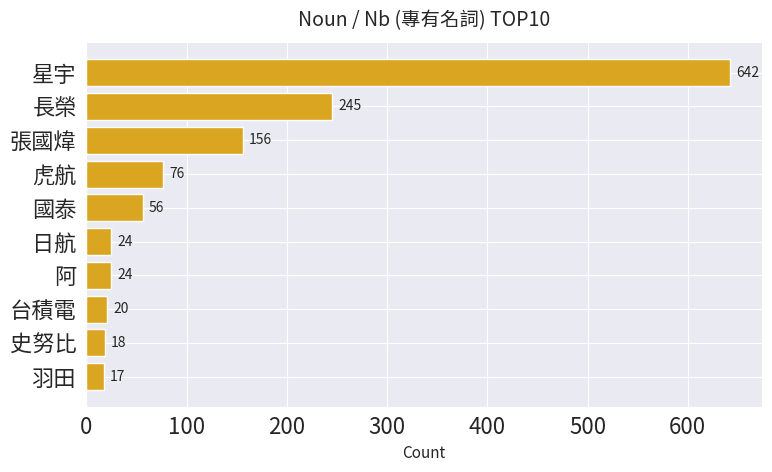

In [124]:
# 7. Noun TOP10

# 排除清單 & 別稱對照（Noun 專用）
not_noun = []  # 有需要排除的詞可以加在這裡
noun_alias = {'星宇航空': '星宇', '董': '張國煒', '董仔': '張國煒'}

def get_pos_words_top(ner_results, pos_prefix, top_n=10,
                      exclude=None, alias=None):
    words = []
    for packed in ner_results['packed_sentence']:
        pairs = re.findall(r'([^\s　]+)\((\w+)\)', packed)
        for word, pos in pairs:
            if pos.startswith(pos_prefix):
                words.append(word)

    return (pd.Series(words)
              .pipe(lambda s: s[~s.isin(exclude)] if exclude else s)
              .replace(alias if alias else {})
              .value_counts()
              .nlargest(top_n)
              .reset_index()
              .set_axis(['Word', 'Count'], axis=1))


# Noun（Nb 或 Na，依需求傳入）
noun_top10 = get_pos_words_top(ner_results, 'Nb', exclude=not_noun, alias=noun_alias)

print("=== Noun (Nb) ==="); print(noun_top10)
plot_top10(noun_top10, 'Noun / Nb (專有名詞) TOP10', color='goldenrod')

=== VC ===
  Word  Count
0   服務     66
1   經營     55
2   加入     42
3   使用     40
4   選擇     38
5   直飛     34
6   新創     32
7   支持     31
8   成立     25
9   投資     25


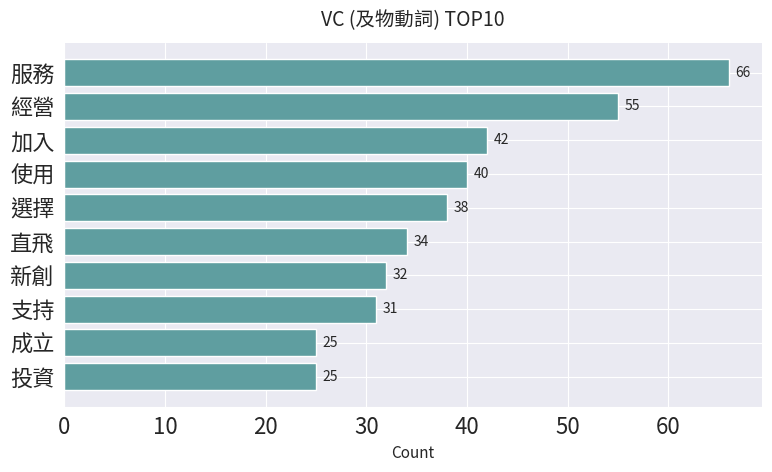

In [125]:
# 8. VC TOP10

def get_pos_words_top(ner_results, pos_prefix, top_n=10,
                      exclude=None, alias=None, min_len=1):
    words = []
    for packed in ner_results['packed_sentence']:
        pairs = re.findall(r'([^\s　]+)\((\w+)\)', packed)
        for word, pos in pairs:
            if pos.startswith(pos_prefix):
                words.append(word)

    return (pd.Series(words)
              .pipe(lambda s: s[s.map(len) >= min_len] if min_len > 1 else s)  # 長度過濾  # 長度過濾
              .pipe(lambda s: s[~s.isin(exclude)] if exclude else s)
              .replace(alias if alias else {})
              .value_counts()
              .nlargest(top_n)
              .reset_index()
              .set_axis(['Word', 'Count'], axis=1))


# VC：過濾長度為 1 的字
vc_top10 = get_pos_words_top(ner_results, 'VC', min_len=2)

print("=== VC ==="); print(vc_top10)
plot_top10(vc_top10, 'VC (及物動詞) TOP10', color='cadetblue')

## 4. Sequence classification

### 4.1 Sentiment Classification
使用 Huggingface 上面已經針對 Sentiment classification 任務 finetune 的 BERT 模型來實作<br>
使用的模型：https://huggingface.co/techthiyanes/chinese_sentiment<br><br>
情緒(start 1到star 5)：<br>
1. Semi-negation<br>
2. Negation<br>
3. Neutral<br>
4. Semi-positive<br>
5. Positive

In [126]:
from transformers import pipeline
import pandas as pd
import torch

# 1. 徹底放棄 GPU，改用 CPU (-1)
# 這樣可以完全避開 CUBLAS_STATUS_NOT_INITIALIZED 錯誤
model_name = "techthiyanes/chinese_sentiment"
model = pipeline('sentiment-analysis', model=model_name, device=-1)

# 2. 準備資料並處理長度與空值
# 我們在模型推論時才下 truncation 參數
sentences = metaData['sentence'].fillna("內容為空").astype(str).tolist()

print(f"正在分析 {len(sentences)} 筆資料（使用 CPU 安全模式）...")

# 3. 批次處理 (Batch processing)
# 這樣寫比 apply 快，且能直接在參數裡解決 512 長度限制
try:
    # batch_size 可以根據你的 RAM 調整，16 或 32 通常很安全
    results = model(sentences, truncation=True, batch_size=16)
    
    # 4. 整理結果
    results_df = pd.DataFrame(results)
    results_df['sentence'] = sentences
    results_df = results_df[['sentence', 'label', 'score']]
    
    print("✅ 分析成功完成！")
    display(results_df.head(10))

except Exception as e:
    print(f"還是發生錯誤: {e}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

正在分析 10370 筆資料（使用 CPU 安全模式）...
✅ 分析成功完成！


,sentence,label,score
0,請問新加坡飛台灣,star 1,0.398183
1,星宇星加坡長榮會怎麼選呢,star 4,0.459202
2,看票價星宇是便宜蠻多的不明白怎麼差那麼多,star 3,0.370034
3,但是如果選星宇累計的里程和星加坡長榮應該是分開的,star 4,0.605914
4,論位置的話,star 4,0.402852
5,這三家哪個會比較大呢,star 4,0.528948
6,還是都用班機時刻選,star 5,0.379050
7,請問大家會怎麼選,star 1,0.388598
8,感謝,star 5,0.439299
9,這有什麼好糾結的,star 5,0.240674


### 分析情緒分類結果

In [127]:
import seaborn as sns
from wordcloud import WordCloud

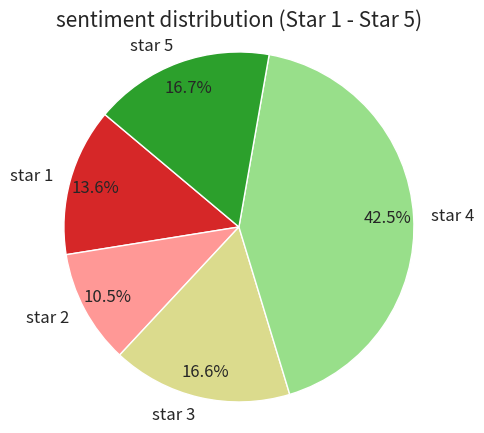

In [128]:
# --- A. 分佈分析 (Distribution) ---
plt.figure(figsize=(12, 5))

# 1. 定義標準順序與對應顏色
sentiment_order = ["star 1", "star 2", "star 3", "star 4", "star 5"]
color_list = ["#d62728", "#ff9896", "#dbdb8d", "#98df8a", "#2ca02c"] # 紅 -> 黃 -> 綠

# 2. 統計數量並強制依照 sentiment_order 排序
# value_counts() 完後用 reindex 重新排列標籤順序
counts = results_df['label'].value_counts().reindex(sentiment_order).fillna(0)

# 3. 繪製圓餅圖
plt.subplot(1, 2, 1)
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=140,              # 調整開始角度讓比例好看一點
    colors=color_list,           # 套用漸層色
    pctdistance=0.85,            # 百分比距離圓心的位置
    textprops={'fontsize': 12}
)

plt.title('sentiment distribution (Star 1 - Star 5)', fontsize=15)
plt.axis('equal')  # 確保圓餅圖是圓的
plt.show()

# # 2. 情緒得分箱型圖 (就像你附件的圖)
# plt.subplot(1, 2, 2)
# sns.boxplot(y=results_df['score'])
# plt.title('情緒得分 (Sentiment Score) 箱型圖')
# plt.ylabel('Confidence Score')

# plt.tight_layout()
# plt.show()

In [129]:
# merge

results_df = results_df.merge(metaData[['sentence', 'artDate']], on='sentence', how='left')

# 將 'artDate' 重新命名為 'date'
results_df.rename(columns={'artDate': 'date'}, inplace=True)

# 檢視結果
display(results_df.head())

,sentence,label,score,date
0,請問新加坡飛台灣,star 1,0.398183,2026-03-14
1,星宇星加坡長榮會怎麼選呢,star 4,0.459202,2026-03-14
2,看票價星宇是便宜蠻多的不明白怎麼差那麼多,star 3,0.370034,2026-03-14
3,但是如果選星宇累計的里程和星加坡長榮應該是分開的,star 4,0.605914,2026-03-14
4,論位置的話,star 4,0.402852,2026-03-14


In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 可以在這裡手動調整您要的週期頻率！
# '2D' = 兩天
# '3D' = 三天
# 'W'  = 一週 (預設以週日為起點，若要週一可用 'W-MON')
# ==========================================
time_freq = '2D'  
# 複製一份資料並確保 date 是 datetime 格式
sent_date = results_df.copy()
sent_date['date'] = pd.to_datetime(sent_date['date'])
# 建立一個名為 'time_period' 的新欄位，會自動把日期歸類到您設定的頻率區間
sent_date['time_period'] = sent_date['date'].dt.floor(time_freq)
sent_date.head()

,sentence,label,score,date,time_period
0,請問新加坡飛台灣,star 1,0.398183,2026-03-14,2026-03-14
1,星宇星加坡長榮會怎麼選呢,star 4,0.459202,2026-03-14,2026-03-14
2,看票價星宇是便宜蠻多的不明白怎麼差那麼多,star 3,0.370034,2026-03-14,2026-03-14
3,但是如果選星宇累計的里程和星加坡長榮應該是分開的,star 4,0.605914,2026-03-14,2026-03-14
4,論位置的話,star 4,0.402852,2026-03-14,2026-03-14


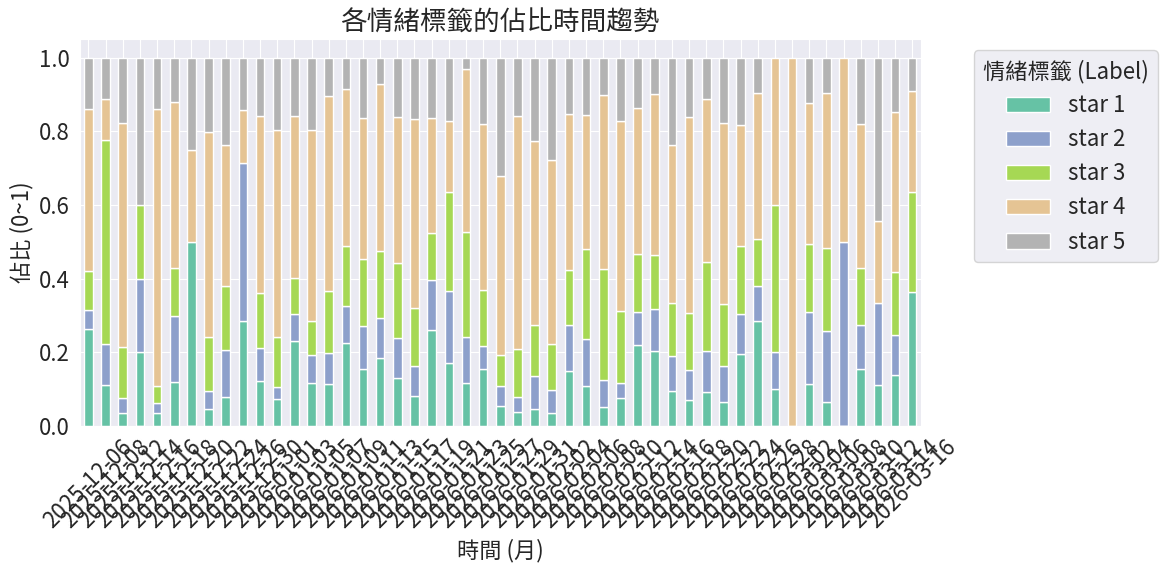

In [131]:
# 建立樞紐分析表：列為月份、欄為 label、值為數量
pivot_df = sent_date.groupby(['time_period', 'label']).size().unstack(fill_value=0)

# 計算每個月份中，各個 label 佔該月總數的比例
pivot_percentage = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# 將 Period 轉為字串以利於畫圖顯示
pivot_percentage.index = pivot_percentage.index.astype(str)

# 畫出 100% 堆疊長條圖
pivot_percentage.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2', edgecolor='white')

plt.title('各情緒標籤的佔比時間趨勢')
plt.xlabel('時間 (月)')
plt.ylabel('佔比 (0~1)')
# 將圖例移到圖表外側
plt.legend(title='情緒標籤 (Label)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


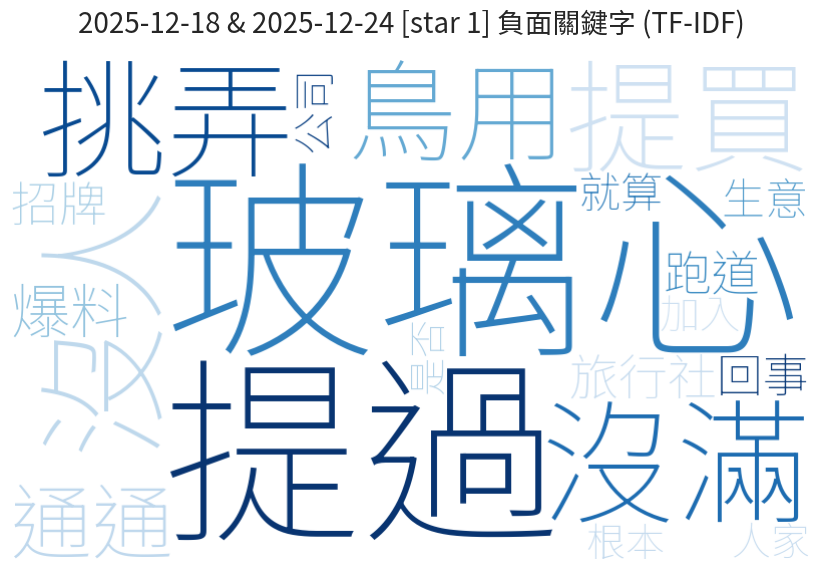

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import jieba
import jieba.analyse
import matplotlib.font_manager as fm
import os
import re

# ================================
# 0. 參數設定與【優化 2 & 6】導入自定義詞典 & 強制合併 Bigram
# ================================
target_dates = ['2025-12-18', '2025-12-24']
target_label = 'star 1'  

# 手動加入行業熱詞與 Bigram，避免被 jieba 切碎，讓 TF-IDF 能精準抓到完整詞彙
domain_words = ['星宇', '桃園機場', '不負責', '延誤', '星宇航空', '長榮航空', '地勤人員', '客服人員', '服務態度']
for w in domain_words:
    jieba.add_word(w)

# 載入專案底下的 user_dict
dict_dir = '/home/chienyu07/SMA_G2_PRJ1/dict/'
if os.path.exists(dict_dir + 'user_dict.txt'):
    jieba.load_userdict(dict_dir + 'user_dict.txt')

# 【優化 4】擴充停用詞表 (排除無意義高頻詞)
custom_stopwords = set()
if os.path.exists(dict_dir + 'stopwords.txt'):
    with open(dict_dir + 'stopwords.txt', 'r', encoding='utf-8') as f:
        custom_stopwords = set([line.strip() for line in f.readlines()])

custom_stopwords.update(['以後', '有人', '覺得', '這版','客桃園','殺成','好像','可沒','了然','提單發', '還力', '其實', '因為', '所以', '然後', '大家', '自己', '可以', '還是', '就是', '什麼', '怎麼'])

# ================================
# 1. 篩選與清理文字
# ================================
filtered_data = sent_date[(sent_date['time_period'].isin(target_dates)) & (sent_date['label'] == target_label)]
text = " ".join(filtered_data['sentence'].dropna().astype(str).tolist())

# 清理網址與非中文字
text = re.sub(r'https?://\S+|www\.\S+', '', text)
text = re.sub(r'[^\u4e00-\u9fff]', '', text) 

# ================================
# 2. 【優化 3 & 5】TF-IDF 權重提取與詞性過濾
# ================================
# extract_tags 內建了 POS 詞性過濾功能
# allowPOS 限制只抓取：n(名詞), v(動詞), a(形容詞), vn(動名詞), an(名形詞)
# 這樣就自動剔除了代名詞(r)、連接詞(c)等無意義詞性
tags_with_tfidf = jieba.analyse.extract_tags(
    text, 
    topK=300,             # 先抓取前 300 個 TF-IDF 最高的詞
    withWeight=True,      # 回傳權重
    allowPOS=('n', 'v', 'a', 'vn', 'an')  
)

# 【優化 1】強制過濾單字 (長度 <= 1) 與停用詞
final_keywords_tfidf = {}
for word, weight in tags_with_tfidf:
    if len(word) >= 2 and word not in custom_stopwords:
        final_keywords_tfidf[word] = weight

# ================================
# 3. 畫出 TF-IDF 權重文字雲
# ================================
font_path = None
for f in fm.fontManager.ttflist:
    if any(name in f.name for name in ['JhengHei', 'YaHei', 'MicroHei', 'CJK', 'WenQuanYi', 'Noto']):
        font_path = f.fname
        break

wc = WordCloud(
    font_path=font_path,
    background_color='white',
    width=800, 
    height=500,
    max_words=100,           
    colormap='Blues'
)

# ⚠️ 使用計算好的 TF-IDF 權重畫圖 (不再是單純看出現次數)
wordcloud = wc.generate_from_frequencies(final_keywords_tfidf)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
date_title = " & ".join(target_dates)
plt.title(f'{date_title} [{target_label}] 負面關鍵字 (TF-IDF)', fontsize=20, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


In [133]:
# ================================
# 4. 檢視原始資料 (探討當時發生了什麼事)
# ================================
# 設定 pandas 顯示選項，避免文字太長被截斷
pd.set_option('display.max_colwidth', None)

print(f"【 目標日期：{', '.join(target_dates)} | 標籤：{target_label} 】")
print(f"共找到 {len(filtered_data)} 筆資料\n")
print("="*60)

# 將留言逐筆印出，方便閱讀
for idx, row in filtered_data.iterrows():
    # 如果你的資料表裡有其他想看的欄位（例如 title, source 等），也可以加進來
    date_str = row['time_period']
    sentence = str(row['sentence']).strip()
    
    # 略過空值
    if not sentence or sentence == 'nan':
        continue
        
    print(f"[{date_str}]")
    print(sentence)
    print("-" * 60)
    
# 如果你只想用 DataFrame 格式在 Jupyter 裡瀏覽，也可以把上面註解掉，直接執行下面這行：
# display(filtered_data[['time_period', 'sentence']])


【 目標日期：2025-12-18, 2025-12-24 | 標籤：star 1 】
共找到 15 筆資料

[2025-12-24 00:00:00]
我上半年提過
------------------------------------------------------------
[2025-12-24 00:00:00]
仁川殺成那樣就算沒滿也不會想加入吧
------------------------------------------------------------
[2025-12-24 00:00:00]
破梗以後華航要飛了嗎
------------------------------------------------------------
[2025-12-24 00:00:00]
這樣轉機客生意是否不好做
------------------------------------------------------------
[2025-12-24 00:00:00]
大家都賺錢不好嗎
------------------------------------------------------------
[2025-12-18 00:00:00]
星宇飛東南亞是為了轉機客桃園以外可沒這回事
------------------------------------------------------------
[2025-12-18 00:00:00]
人家富國島通通是旅行社包
------------------------------------------------------------
[2025-12-18 00:00:00]
至少跟單發繼續飛數個小時就是不轉降至今無人負責甚至公司還力挺的真的是不錯了
------------------------------------------------------------
[2025-12-18 00:00:00]
然後別忘了釜山差點撞山撞地甚至降錯跑道緊急重飛被爆料了公司也沒關係
------------------------------------------------------------
[2025-12-18 00:00:00]
都沒人負責
----

## 5. Text Clustering

以下使用 BERTopic 來實作 BERT-based 的 Text Clustering，並介紹 clustering-based 的主題模型<br>
BERTopic: https://maartengr.github.io/BERTopic/index.html<br><br>

![image.png](static/proj3-bertopic.png)

簡單介紹BERTopic套件的模組架構，每一列的組件代表不同的處理步驟，主要可以分為兩個階段，其中相同顏色的組件代表可替換的選項：<br>
- **Topic Creation 主題分群**
    - **Embeddings**: 使用語言模型將文本句子轉換成向量，用於進行分群
    - **Dimension Reduction**: 把高維度的語意向量降維方便後續處理
    - **Clustering**: 把降維後的語意向量進行分群（主題）
---
- **Topic Representation 主題表示**
    - **Tokenizer**: 將文本句子的詞進行轉換成可計算的表示
    - **Topic Representation**: 從每個主題中抽取出主題的關鍵代表詞
---
除此之外，新版本的BERTopic也提供了方法去進一步微調每個主題表示，可以使用GPT、KEYBERT、Spacy等模型或方法去調整並找出更好的主題模型的代表詞或標籤。

#### 5.1 基本用法介紹

In [36]:
docs = en_origin_data['sentence'].tolist()

# 定義不同 layer 所要使用的模型與方法
embedding_model = "all-MiniLM-L6-v2" # Embeddings layer
hdbscan_model = HDBSCAN() # Clustering layer
vectorizer_model = CountVectorizer()

topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model)
topics, probs = topic_model.fit_transform(docs[:500])

In [37]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,135,-1_the_of_and_you,"[the, of, and, you, he, to, her, that, in, was]","[She was shewn into the breakfast-parlour, whe..."
1,0,44,0_you_it_not_be,"[you, it, not, be, but, will, no, to, are, am]","[""Upon my word!--Well, that was very decided i..."
2,1,42,1_bingley_mr_and_his,"[bingley, mr, and, his, of, had, was, the, to,...",[His sisters were very anxious for his having ...
3,2,38,2_bennet_mrs_netherfield_mr,"[bennet, mrs, netherfield, mr, that, of, the, ...",[Mrs. Bennet was prevented replying by the ent...
4,3,33,3_darcy_mr_to_his,"[darcy, mr, to, his, of, the, and, at, was, with]",[Between him and Darcy there was a very steady...
5,4,22,4_he_his_and_was,"[he, his, and, was, there, in, manners, than, ...","[and turning round, he looked for a moment at ..."
6,5,20,5_eliza_dance_danced_he,"[eliza, dance, danced, he, with, the, you, mis...",[He paused in hopes of an answer; but his comp...
7,6,18,6_oh_officers_ah_secret,"[oh, officers, ah, secret, names, connections,...","[""Oh!, ""Oh!, ""Oh!]"
8,7,18,7_you_agreeable_flatter_nerves,"[you, agreeable, flatter, nerves, agree, yet, ...","[""I do not know how you will ever make him ame..."
9,8,18,8_is_enough_love_it,"[is, enough, love, it, woman, of, but, she, mu...","[When she is secure of him, there will be leis..."


In [38]:
# 列出Topic 6的關鍵字和其對應的c TF-IDF分數
topic_model.get_topic(6)

[('oh', 0.5539331805919395),
 ('officers', 0.24018609271246166),
 ('ah', 0.09084738398376577),
 ('secret', 0.09084738398376577),
 ('names', 0.09084738398376577),
 ('connections', 0.09084738398376577),
 ('length', 0.09084738398376577),
 ('answering', 0.08053578649084926),
 ('astonishment', 0.08053578649084926),
 ('lodgings', 0.08053578649084926)]

In [39]:
# 列出前10筆文章的BERTopic資訊
doc_topic_info = topic_model.get_document_info(docs[:500])
doc_topic_info.head(10)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,﻿TPRIDE & PREJUDICE.,-1,-1_the_of_and_you,"[the, of, and, you, he, to, her, that, in, was]","[She was shewn into the breakfast-parlour, whe...",the - of - and - you - he - to - her - that - ...,0.000000,False
1,"It is a truth universally acknowledged, that a...",17,17_single_fortune_man_or,"[single, fortune, man, or, universally, agreea...","[""Is he married or single?"", A single man of l...",single - fortune - man - or - universally - ag...,1.000000,True
2,However little known the feelings or views of ...,-1,-1_the_of_and_you,"[the, of, and, you, he, to, her, that, in, was]","[She was shewn into the breakfast-parlour, whe...",the - of - and - you - he - to - her - that - ...,0.000000,False
3,"""My dear Mr. Bennet,"" said his lady to him one...",2,2_bennet_mrs_netherfield_mr,"[bennet, mrs, netherfield, mr, that, of, the, ...",[Mrs. Bennet was prevented replying by the ent...,bennet - mrs - netherfield - mr - that - of - ...,0.592052,False
4,Mr. Bennet replied that he had not.,2,2_bennet_mrs_netherfield_mr,"[bennet, mrs, netherfield, mr, that, of, the, ...",[Mrs. Bennet was prevented replying by the ent...,bennet - mrs - netherfield - mr - that - of - ...,1.000000,False
5,"""But it is,"" returned she; ""for Mrs. Long has ...",15,15_long_mrs_will_it,"[long, mrs, will, it, told, introduce, him, th...",[But I can guess how it was; every body says t...,long - mrs - will - it - told - introduce - hi...,1.000000,False
6,Mr. Bennet made no answer.,2,2_bennet_mrs_netherfield_mr,"[bennet, mrs, netherfield, mr, that, of, the, ...",[Mrs. Bennet was prevented replying by the ent...,bennet - mrs - netherfield - mr - that - of - ...,1.000000,False
7,"""Do not you want to know who has taken it?""",0,0_you_it_not_be,"[you, it, not, be, but, will, no, to, are, am]","[""Upon my word!--Well, that was very decided i...",you - it - not - be - but - will - no - to - a...,0.722062,False
8,cried his wife impatiently.,-1,-1_the_of_and_you,"[the, of, and, you, he, to, her, that, in, was]","[She was shewn into the breakfast-parlour, whe...",the - of - and - you - he - to - her - that - ...,0.000000,False
9,"""_You_ want to tell me, and I have no objectio...",0,0_you_it_not_be,"[you, it, not, be, but, will, no, to, are, am]","[""Upon my word!--Well, that was very decided i...",you - it - not - be - but - will - no - to - a...,0.721104,False


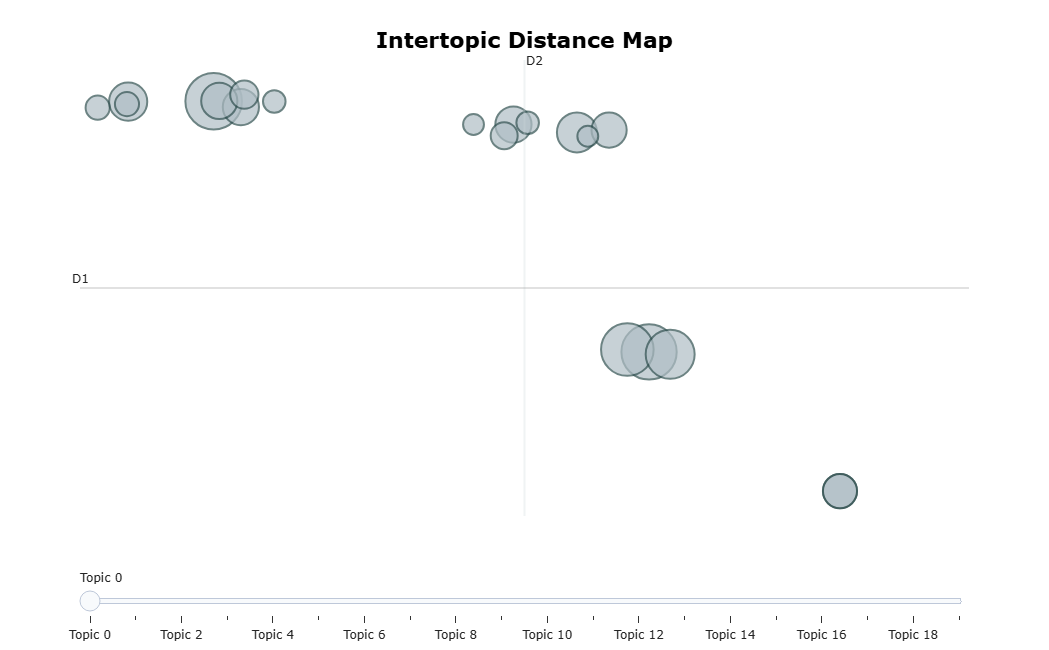

In [40]:
# 視覺化主題分布：圓圈大小是主題的大小，圓圈的距離是主題之間的相似度
topic_model.visualize_topics()

#### 5.2 Embedding model<br>
BERTopic 支援多種 embedding 模型與方法，包含基本的 Huggingface 模型，也提供了 LLM-based 的 embedding 可做選擇。<br>
更多請參考文件：https://maartengr.github.io/BERTopic/getting_started/embeddings/embeddings.html#scikit-learn-embeddings

In [41]:
# 使用 sentence_transformers 相關語言模型作為 embedding_model
sentence_model = SentenceTransformer("google-bert/bert-base-uncased")

# 定義不同 layer 所要使用的模型與方法
hdbscan_model = HDBSCAN()
vectorizer_model = CountVectorizer()

# 將 BERTopic 的 embedding_model 替換為其他模型（sentence_model）
embed_topic_model = BERTopic(embedding_model=sentence_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model)
topics, probs = embed_topic_model.fit_transform(docs[:500])

In [42]:
# import openai
# from bertopic.backend import OpenAIBackend

# 也可以使用 OpenAI API 來獲取性能更強大的語言模型作為 embedding_model
# client = openai.OpenAI(api_key="請替換為你的 openai key")
# openai_embedding_model = OpenAIBackend(client, "text-embedding-ada-002")

# 定義不同 layer 所要使用的模型與方法
# hdbscan_model = HDBSCAN()
# vectorizer_model = CountVectorizer()

# 將 BERTopic 的 embedding_model 替換為其他模型（openai_embedding_model）
# openai_topic_model = BERTopic(embedding_model=openai_embedding_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model)
# topics, probs = openai_topic_model.fit_transform(docs[:500])

#### 5.3 Clustering model<br>
參考文件：https://maartengr.github.io/BERTopic/getting_started/clustering/clustering.html

調整 topic modeling 流程中的 clustering 算法

In [43]:
# 使用 KMeans 作為分群算法，需要指定分群個數
cluster_model = KMeans(n_clusters=10)

# 定義不同 layer 所要使用的模型與方法
embedding_model = "all-MiniLM-L6-v2"
vectorizer_model = CountVectorizer()

# 將 BERTopic 的 hdbscan_model 替換為其他模型（cluster_model）
kmeans_topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=cluster_model, vectorizer_model=vectorizer_model)
topics, probs = kmeans_topic_model.fit_transform(docs[:500])

kmeans_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,73,0_it_you_not_is,"[it, you, not, is, but, do, to, that, if, in]","[""But if he does it any more I shall certainly..."
1,1,68,1_he_and_the_her,"[he, and, the, her, of, in, was, had, she, to]","[They were rather handsome, had been educated ..."
2,2,63,2_bingley_the_and_of,"[bingley, the, and, of, mr, to, was, her, in, ...",[His sisters were very anxious for his having ...
3,3,61,3_of_is_to_you,"[of, is, to, you, be, are, in, the, have, or]",[They always continue to grow sufficiently unl...
4,4,52,4_bennet_mrs_mr_of,"[bennet, mrs, mr, of, the, to, that, and, said...","[Mr. Bennet replied that he had not., ""How goo..."
5,5,52,5_darcy_to_the_mr,"[darcy, to, the, mr, with, his, and, at, of, d...","[And taking her hand, he would have given it t..."
6,6,48,6_you_it_to_and,"[you, it, to, and, for, not, long, the, him, w...","[But if _we_ do not venture, somebody else wil..."
7,7,37,7_jane_was_her_to,"[jane, was, her, to, she, elizabeth, and, the,...","[She was shewn into the breakfast-parlour, whe..."
8,8,26,8_oh_officers_you_last,"[oh, officers, you, last, did, the, to, length...","[""Oh!, ""Oh!, ""Oh!]"
9,9,20,9_lucas_to_the_miss,"[lucas, to, the, miss, william, and, sir, his,...",[Sir William Lucas had been formerly in trade ...


查看 text clustering 結果

In [44]:
topics[:10]

[9, 3, 3, 4, 4, 6, 4, 0, 2, 0]

#### 5.4 套用於中文<br>
為了套用到中文文章，各元件必須修改為支援中文的方法，主要針對 embedding model 以及 tokenizer

In [134]:
# 中文文章
docs_zh = metaData['sentence'].tolist()

# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')

# 新增 stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopwords = [line.strip() for line in f.readlines()]

# 參數形式手動加入停用字
stopwords_manual = ["知道", "現在", "本來", "一直", "看到", "目前", "不用", "直接", "這種", "一點", "根本", "表示", "一下", "反正", "繼續",
    "好像", "好了", "感覺", "會不會", "有沒有", "看看", "幹嘛", "有夠", "笑死", "XD", "XDD", "咩", "阿彌陀佛", "其實", "因為", "所以", "然後", 
    "就是", "還是", "可以", "什麼", "怎麼", "完全", "原來", "對此", "大家", "自己", "有人", "一堆", "太多", "這麼多", "裡面","地方", "事情", 
    "東西", "幾個", "兩個", "今天", "去年", "今年", "明年", "未來", "以後", "以前", "之後", "過去", "最近", "最後", "一次", "一年", "幾年",
    "期間", "每年", "樓上", "原文", "標題", "來源", "連結", "引述", "銘言", "網友", "討論", "分享", "新聞", "謝謝", "10", "12", "14", "15", 
    "101", "339", "359", "規", "法", "第台", "之給", "從選", "雀食", "原", "可以", "只是", "他們", "而且", "的話", "說", "想", "做", "買", 
    "中", "台", "開", "飛", "月", "年", "問題", "這才", "這就", "好談", "用途", "硬體", "負責", "用詞", "搞定", "懂", "否", "讓你在", 
    "啊啊啊", "操心", "推推", "嘻嘻", "真", "時間", "方式", "使用", "產生", "根本", "無法", "可能", "應該", "比較", "需要", "要求",
    "相信", "對內", "問得", "不容", "日期", "清票", "主打", "有心", "找", "發", "死", "笑", "洗", "只能", "只會",
    "還說", "喔", "家", "玩", "坐", "稱", "打開", "整個", "哪來", "可惜", "正常", "認為", "通常", "新", "線", "搭", "市場", "成本", "服務",
    "需求", "距離", "方便", "配置", "使用", "包含", "屬於", "設置", "進入", "前方", "務", "艙個", "洗三", "樣用", "在內", "肯花給",
    "跟樣", "僅在", "至度", "已調", "案", "船過", "水無痕", "當的", "哪來" "公司", "新", "找", "賺", "加入", "經營", "落地",
    "管理層", "子公司", "回去", "態度", "願意", "不發", "競爭", "發個", "能力", "薪水", "奇怪", "可憐", "可怕", "實在", "真棒", "太狠",
    "太棒了", "兩眼", "無聊", "好酷", "舒服", "不演", "真是", "有趣", "不錯", "值得", "炸裂", "滿滿", "歡樂", "悲哀", "默契", "強人所難", "真懂花",
    "很美給", "講再", "很妙", "小物", "講道", "美呆", "開胃", "布丁", "西式", "香氣", "最頂", "搭配",
    "前菜", "依序", "迷霧", "套餐", "飲料", "麵中", "煙底", "炊飯", "白飯", "烏綠春", "氣泡", "照燒", "米飯",
    "真給當", "賺賺", "星宇養", "董董長", "根本就是", "沒賺", "雙倍", "飽飽", "全薪", "加班", "不給", "客人", "體機樣", "開廣體機", "載的夠", "廣體客",
    "擁擠", "弄個", "不見得", "兩大", "減班", "遠端", "機坪", "確定", "持續", "但定", "數年", "短短幾天", "不久", "七月",
    "促銷", "有波", "下雪", "短短", "半夜", "地震", "冬季", "春節", "熱門", "顯示", "旺季", "發生", "成立", "慢慢", "講究", "搶手", "就燒", "勤務",
    "容易", "共鳴", "增班", "稍微", "租借", "偏好", "想想", "大佬", "食物", "出現", "別家", "多點", "位置", "系統", "不夠",
    "喜歡", "真的", "應該", "可能", "比較", "需要", "要求", "相信", "正常", "認為", "通常", "整個", "哪來", "可惜", "問題", "時間", "方式", "使用",
    "產生", "根本", "無法", "推推", "嘻嘻", "清票", "主打", "有心", "還說", "喔", "家", "玩", "坐", "稱", "打開", "配置", "包含",
    "屬於", "設置", "進入", "前方", "務", "艙個", "洗三", "樣用", "在內", "肯花給", "個貴", "跟樣", "僅在", "至度", "已調", "案", "船過", "水無痕", "當的"]
stopwords.extend(stopwords_manual)

# 設定中文 embedding model
bert_sentence_model = SentenceTransformer("google-bert/bert-base-chinese")

# 將中文文章轉換為 embedding
embeddings = bert_sentence_model.encode(docs_zh, show_progress_bar=True)

# 定義不同 clustering layer 所要使用的模型與方法（就用 default 的 HDBSCAN）
hdbscan_model = HDBSCAN()

# 定義一個適合中文的分詞函數
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

# 建立一個使用 jieba 分詞的 CountVectorizer
jieba_vectorizer = CountVectorizer(tokenizer=tokenize_zh, stop_words=stopwords, analyzer='word', token_pattern=u"(?u)\\b\\w+\\b")

# 使用 BERTopic 進行主題模型建立
zh_topic_model = BERTopic(embedding_model=bert_sentence_model, vectorizer_model=jieba_vectorizer, verbose=True, top_n_words=30)
topics, probs = zh_topic_model.fit_transform(docs_zh, embeddings)

zh_topic_model.get_topic_info()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/325 [00:00<?, ?it/s]

2026-05-18 07:41:34,436 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 07:41:58,471 - BERTopic - Dimensionality - Completed ✓
2026-05-18 07:41:58,473 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 07:41:58,821 - BERTopic - Cluster - Completed ✓
2026-05-18 07:41:58,825 - BERTopic - Representation - Fine-tuning topics using representation models.
Building prefix dict from c:\Users\User\SMA_G2_PRJ1\dict\dict.txt.big ...
Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u2dee89b731aefadf6546f7ceed286487.cache
Loading model cost 0.945 seconds.
Prefix dict has been built successfully.
2026-05-18 07:42:00,342 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5797,-1_ _飛機_星宇_長榮,"[ , 飛機, 星宇, 長榮, 公司, 日本, 航空, 華航, 票價, 台灣, 員工, 年終, 航線, 精品, 高雄, 錢, 成田, 機場, 航空業, 航點, 航空公司, 賣, 前, 桃園, 便宜, 疫情, 董, 機票, 吃, 旅客]","[飛機沒在賺錢, 個月的是長榮, 接下來如果繼續要買飛機]"
1,0,958,0_員工_公司_股票_股東,"[員工, 公司, 股票, 股東, 老闆, 跳槽, 賺錢, 新創, 星宇, 錢, 股價, , 星粉, 資方, 企業, 反串, 講話, 年終, 時艱, 賭, 選擇權, 共體, 虧, 工作, 堆, 賠錢, 罷工, 文章, 勞工, 努力]","[股東投資沒賺錢, 不然拿去買股票, 那就未來賺錢不要出來靠北公司發的少啊信不信這些人賺錢靠北少賠錢也是出來靠北少覺得我就是出來賺錢的公司好壞跟我無關那就不要賺錢了出來說發年終賠錢了也出來說發年終星宇也不是發展很久的公司創業初期誰不知道會虧講難聽不爽就真的走吧覺得同業發展的好那就趕快去其他同業吧公司財報攤開來就是這樣覺得公司發展不合你想要的那就是閃人今天老闆可不是賺錢還說我賺錢不關你事如果只想著過很賺的那段也行啊那就是先走未來再來反正只想要現在賺錢的公司在做大的資本支出的你不要你也可以賭未來如果他成長了以後還收你也可賭現在虧未來賺他會分而繼續待都是自己選擇你也可以賭這老闆就是不會成功那就是快逃進新公司不就是這樣嗎賭這間公司未來會成功怎會有初期就認為要跟同業樣猛的薪水你提的配股也是種方式啊但你要錢基本上不可能啦]"
2,1,303,1_釜山_首爾_布拉格_韓國,"[釜山, 首爾, 布拉格, 韓國, 蘇黎世, 日本, 轉機, 芬蘭, 歐洲, 曼谷, 瑞士, 東京, 航點, 仁川, 台灣, 沖繩, 機場, 捷克, 神戶, 出發, 熊本, 東南亞, 桃園, 赫爾辛基, 便宜, 郵輪, 旅行團, 波蘭, 高鐵, 歐積]","[分別是瑞士蘇黎世捷克布拉格韓國釜山印尼峇里, 韓國有競爭力的只有首爾釜山吧其他利潤應該都不如日本二三線, 釜山距離比首爾近票價又高]"
3,2,188,2_頭等艙_艙_商務_經濟艙,"[頭等艙, 艙, 商務, 經濟艙, 廁所, 席, 豪華, 制止, 乘客, 優先, 專用, 客戶, 頭等, 座位, 旅客, 艙席, 布簾, 用餐, 四艙, 前排, 漢典, 豪經艙, 陳, 提供, 睡衣, 機上, 洗手間, 過夜, 排隊, 坐著]","[經濟艙可以去用商務艙廁所嗎, 商務艙乘客不能上頭等艙廁所, 而是有人坐頭等艙以後的商務艙廁所問題呀]"
4,3,158,3_年終_少_差_吵,"[年終, 少, 差, 吵, 太, 白癡, 發不出, 發不, 年關, 年算, 那年, 同業, 不見, 慘, 每周, 四月, 十年, 好不好, , 哭, 新年快樂, 換新, 這了, 改發, 聰明, 惹個, 這靠, 慘嗎, 還差, 我媽開]","[年終本來就是多的, 年終發個月也可以比照, 年終不給]"
...,...,...,...,...,...
99,98,11,98_熊本_加坡_檳城_吉隆坡,"[熊本, 加坡, 檳城, 吉隆坡, 里島, 峇, 公佈, 多個, 宮古島, 新加坡, 難, 曼谷, , , , , , , , , , , , , , , , , , ]","[熊本, 熊本, 熊本]"
100,99,10,99_被騙_煩惱_糾結_這有,"[被騙, 煩惱, 糾結, 這有, 後悔, 認真, 擔心, 維修, 太, , , , , , , , , , , , , , , , , , , , , ]","[幹嘛替他們操心煩惱, 不要被騙去買就好, 這有什麼好糾結的]"
101,100,10,100_羨慕_ __,"[羨慕, , , , , , , , , , , , , , , , , , , , , , , , , , , , , ]","[嘻嘻嘻, 推推羨慕, 真羨慕]"
102,101,10,101_價格_上不去_下降_保證,"[價格, 上不去, 下降, 保證, 品質, 上揚, 何不, 本家, 說出, 還貴, 坐等, 賣, 多到, 卡, 請問, 重點, 先, , , , , , , , , , , , , ]","[那怎麼保證服務品質不下降, 那怎麼保證服務品質不下降, 那怎麼保證服務品質不下降]"


In [135]:
zh_topic_model.visualize_topics()

In [141]:
# 估算每個文件對BERTopic每個主題的機率分布
topic_distr, _ = zh_topic_model.approximate_distribution(docs_zh)

100%|██████████| 11/11 [00:01<00:00,  6.12it/s]


In [142]:
# 以第1個文件為例，列出這份文件對每個主題的機率分布
zh_topic_model.visualize_distribution(topic_distr[1])

In [144]:
# 列出主題的代表詞和其對應的權重
zh_topic_model.get_topic(2)

[('頭等艙', 0.1421913553230289),
 ('艙', 0.12399143127292081),
 ('商務', 0.1125675965701677),
 ('經濟艙', 0.08614887621333578),
 ('廁所', 0.07385048390133464),
 ('席', 0.04085330297565855),
 ('豪華', 0.03598066326982989),
 ('制止', 0.029730207482066326),
 ('乘客', 0.02556707178564513),
 ('優先', 0.02534511768487637),
 ('專用', 0.022912032573219873),
 ('客戶', 0.02137570173285286),
 ('頭等', 0.0195897740130341),
 ('座位', 0.019570125031871652),
 ('旅客', 0.019561626384965232),
 ('艙席', 0.019221690957811326),
 ('布簾', 0.017602313725433093),
 ('用餐', 0.016458274243817236),
 ('四艙', 0.015280677000002383),
 ('前排', 0.015280677000002383),
 ('漢典', 0.014855746536603107),
 ('豪經艙', 0.014416268218358494),
 ('陳', 0.014250467821901907),
 ('提供', 0.013978660737051181),
 ('睡衣', 0.013747219543931922),
 ('機上', 0.013728344628303352),
 ('洗手間', 0.013492044101108153),
 ('過夜', 0.01168099564692542),
 ('排隊', 0.011141809902452329),
 ('坐著', 0.011001086687317255)]

查看特定文章的主題分佈

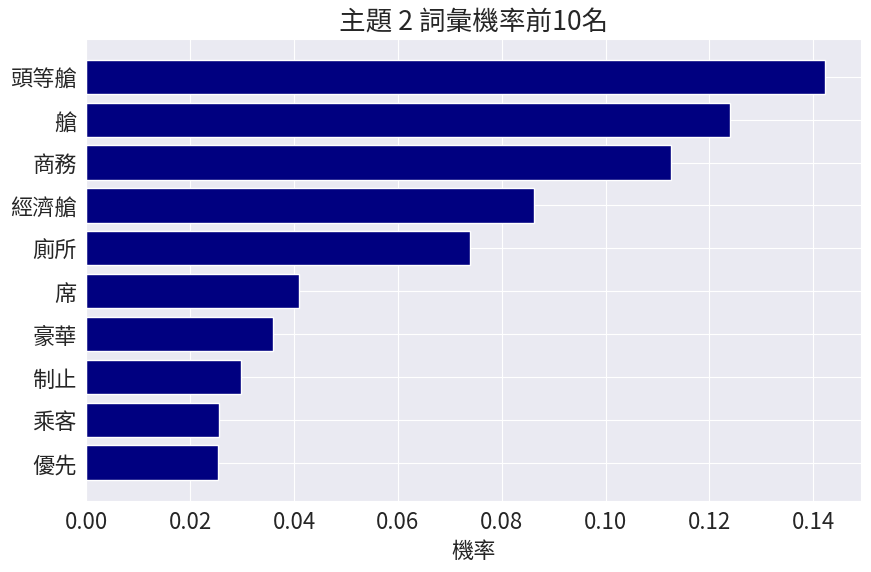

In [146]:
# 視覺化顯示主題-詞彙分佈
topic_n = 2
data = zh_topic_model.get_topic(topic_n)

# 轉換為DataFrame
df = pd.DataFrame(data, columns=['word', 'prob'])
df = df[df['word'] != ' ']

# 根據prob排序並選出前10名
top_10 = df.sort_values('prob', ascending=False).head(10)

# 畫出長條圖
plt.figure(figsize=(10,6))
plt.barh(top_10['word'], top_10['prob'], color='navy')
plt.xlabel('機率')
plt.title(f'主題 {topic_n} 詞彙機率前10名')
plt.gca().invert_yaxis()
plt.show()

#### 5.5 用模型進行主題標籤的調整
新版本的BERTopic提供許多方法供我們調整以c TF-IDF的主題表示，讓我們能得到更能準確描述各個文件集合的字詞去描述每個主題。

目前的Representation方法大致分成兩種：
- 非生成模型：專注於調整或改善每個主題表示的關鍵字
- 生成模型：會根據每個主題的詞語和代表文件，去標記或總結主題

在這邊我們先以KeyBERT非生成模型方法做示範如何去調整BERTopic的主題表示詞語

##### KeyBERT方法說明
---
KeyBERT是一種文本關鍵字提取模型，其方法是透過計算文本中每個N-gram或者token字詞和文件本身之間得BERT embedding的餘弦相似度，去找到文件的關鍵字。
BERTopic根據KeyBERT的方法去建立了一個應用於每個Topic的關鍵字提取流程，架構如下圖所示。

![image.png](static/proj3-keybert.png)

1. 首先針對Topic n，會先依據這個主題的c TF-IDF去找出最能代表主題的幾篇文件，和最能代表主題的幾個候選關鍵代表字。
    - 候選關鍵代表字是根據c TF-IDF的大小去排序，找出前Ｎ個代表字
    - 主題的代表文件挑選方法是比較主題的c TF-IDF和每篇文件的c TF-IDF
2. 接著會利用BERT去產生這些文件和候選代表字的Embedding向量
    - 其中所有代表文件的Embedding向量會取平均作為這個Topic n的向量表示
3. 接著去計算Topic n的向量表示和每個候選代表字的Embedding向量的相似度去找出這個Topic n的最終代表字

根據這個調整後KeyBERT的方法，就能快速的去調整並找出每個主題的代表關鍵字。

In [147]:
from bertopic.representation import ( KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech )
# KeyBERT (考慮語意相似度)
keybert = KeyBERTInspired()

# MMR (考慮詞彙多樣性)
mmr = MaximalMarginalRelevance(diversity=0.3)

# 設定HDBscan模型
hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=30)

# 定義我們要用到的representation model（同學如果想比較其他模型可以在這邊加入其他模型方法）
representation_model = {
    "KeyBERT": keybert,
    "MMR": mmr,
}

In [148]:
# 建立BERTopic模型
representation_topic_model = BERTopic(
  # Sub-models
  embedding_model=bert_sentence_model,
  vectorizer_model=jieba_vectorizer,
  # 設定Representation model
  representation_model=representation_model,
  # Hyperparameters
  top_n_words=30,
  verbose=True
)

# Train model
topics, probs = representation_topic_model.fit_transform(docs_zh, embeddings)

2026-05-18 07:45:02,426 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 07:45:04,019 - BERTopic - Dimensionality - Completed ✓
2026-05-18 07:45:04,021 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 07:45:04,343 - BERTopic - Cluster - Completed ✓
2026-05-18 07:45:04,346 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 07:45:09,920 - BERTopic - Representation - Completed ✓


In [149]:
# 觀察KeyBERT微調後的主題表示
representation_topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,5932,-1_ _長榮_星宇_飛機,"[ , 長榮, 星宇, 飛機, 年終, 航空, 公司, 華航, 日本, 航線, 票價, 台灣, 高雄, 員工, 機場, 航點, 桃園, 成田, 精品, 航空公司, 便宜, 錢, 轉機, 航空業, 董, 賣, 堆, 機票, 賺錢, 不好]","[航空公司, 航空業, 希望, 老闆, 飛機, 民航局, 空服員, 回來, 聽到, 不到]","[星宇, 飛機, 航空, 公司, 華航, 航線, 航空公司, 轉機, 航空業, 機票]","[有年終不錯了, 新聞連結長榮虎航人家也遇到疫情, 長榮不給開啊]"
1,0,928,0_員工_公司_股票_股東,"[員工, 公司, 股票, 股東, 老闆, 新創, 賺錢, 跳槽, 星宇, 錢, 股價, 星粉, 資方, , 反串, 工作, 年終, 講話, 虧, 時艱, 賭, 賠錢, 堆, 前景, 文章, 護航, 不敢, 努力, 共體, 跳]","[老闆, 股東, 公司, 股票, 有錢, 賠錢, 賺錢, 阿姨, 兩家, 企業]","[員工, 公司, 股東, 老闆, 星宇, 資方, 賠錢, 文章, 護航, 努力]","[發股票吧, 這時候星粉又吹星宇是新創公司了新創公司是那些企業發展根本毫無前景, 公司怎麼對待員工]"
2,1,200,1_頭等艙_艙_商務_經濟艙,"[頭等艙, 艙, 商務, 經濟艙, 廁所, 席, 豪華, 乘客, 旅客, 制止, 優先, 抱怨, 專用, 客戶, 座位, 艙席, 但同, 班機, 布簾, 前排, 四艙, 漢典, 豪經艙, 陳, 提供, 睡衣, 機上, 空服員, 洗手間, 頭等]","[經濟艙, 頭等艙, 豪經艙, 空服員, 艙席, 洗手間, 工程師, 歡迎光臨, 座位表, 機上]","[頭等艙, 經濟艙, 乘客, 抱怨, 艙席, 四艙, 豪經艙, 機上, 空服員, 洗手間]","[商務艙要求真多, 經濟艙可以去用商務艙廁所嗎, 商務艙乘客不能上頭等艙廁所]"
3,2,170,2_精_學人_加油_宣傳,"[精, 學人, 加油, 宣傳, 行走, 說明, 關鍵, 推, 數據, 維修, , 撐, 花股, 縮網, 我律, 有調, 激下, 洨, 毋湯, 第薪, 薪酸, 民報, 罷成, 幅, 媒, 菜色, 將全, 壓縮, 已改, 結語]","[加油, 放油, 加簾, 高招, 速, 增租, 入股, 專打, 速加, 第薪]","[加油, 數據, 花股, 縮網, 我律, 激下, 毋湯, 薪酸, 民報, 將全]","[加油, 學人精, 學人精]"
4,3,139,3_帥_太_超_讚,"[帥, 太, 超, 讚, 美, 越, 鬼才, 夠爛, 好美, 嬌貴, 有樣, 洗白, 炫, 真有夠, 太帥, 示警, 粗暴, 開價, 累, 義, 蠻爛, 貨, 超呵, 超鐵, 低調, 造型, 厲害, 欸, 好奇, ]","[真有夠, 誇張, 好慘, 好看, 很棒, 厲害, 超呵, 懂嗎, 拜託, 好美]","[鬼才, 夠爛, 洗白, 真有夠, 太帥, 粗暴, 蠻爛, 超呵, 低調, 厲害]","[這個帥, 帥炸裂啦, 帥哦]"
...,...,...,...,...,...,...,...
110,109,11,109_拿來_那虧_會計_手下,"[拿來, 那虧, 會計, 手下, 業都, 門檻, 服務業, 減薪, 了還, 發給, 心態, 有個, 老闆, 行業, 更好, 辛苦, 科技, 不敢, 離職, 是不是, 錢, 公司, 員工, , , , , , , ]","[是不是, 減薪, 拿來, 那虧, 老闆, 更好, 辛苦, 服務業, 了還, 離職]","[拿來, 服務業, 減薪, 了還, 心態, 老闆, 更好, 辛苦, 離職, 是不是]","[你是老闆會覺得拿來, 那虧錢要不要減薪, 拿來發給員工不是更好]"
111,110,10,110_邏輯_薩頓_定律_發現異常,"[邏輯, 薩頓, 定律, 發現異常, 常見, 推論, 正確, 士氣, 未, 空, 考慮, , , , , , , , , , , , , , , , , , , ]","[邏輯, 推論, 定律, 發現異常, 考慮, 正確, 薩頓, 空, 常見, 士氣]","[邏輯, 薩頓, 定律, 發現異常, 常見, 推論, 正確, 士氣, 空, 考慮]","[這邏輯, 的基本邏輯, 薩頓定律]"
112,111,10,111_等明_太久_年內_那年,"[等明, 太久, 年內, 那年, 說好, 四個, 發不出, 加發, 再來, 更好, 年底, 美東, 先, 歐洲, 年終, , , , , , , , , , , , , , , ]","[發不出, 說好, 那年, 更好, 再來, 年底, 加發, 太久, 四個, 年終]","[太久, 那年, 說好, 四個, 發不出, 加發, 再來, 更好, 年底, 歐洲]","[過去年內拿拿要趕快找更好的, 等他發四個月那年再去搭, 歐洲還要等明年底也太久]"
113,112,10,112_講白_實說_練功_場,"[講白, 實說, 練功, 場, 說真的, 嚴格, 說白了, 講, , , , , , , , , , , , , , , , , , , , , , ]","[說白了, 說真的, 講白, 實說, 練功, 講, 場, 嚴格, , ]","[講白, 實說, 練功, 場, 說真的, 嚴格, 說白了, 講, , , , , , , , , , , , , , , , , , , , , , ]","[講白了, 講白了, 講白了]"


主題表示的微調方法除了KeyBERT以外還有MMR、Spacy等多種方法，除此之外也能進一步透過生成模型的方法進行主題的標籤生成，例如：GPT、Llama等，由於教材篇幅以及方法的複雜性原因，這邊另外提供同學們BERTopic的官方網站說明以及Llama示範的colab程式碼。

有興趣的同學可以參考並嘗試替換不同方法去調整主題的代表詞，或者進一步用生成模型對每個生成主題進行標記或者總結，去更好的解釋每個主題的內容。

- BERTopic官網說明：https://maartengr.github.io/BERTopic/getting_started/representation/representation.html
- 使用地端Llama模型進行BERTopic總結：https://colab.research.google.com/drive/1QCERSMUjqGetGGujdrvv_6_EeoIcd_9M?usp=sharing


## 6. (補充) RAG

In [74]:
import anthropic
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

with open("./api_key.txt", "r") as f:
    api_key = f.read().strip()

client = anthropic.Anthropic(api_key=api_key)

In [77]:
topic_summaries = {}

for topic_id in range(min(10, len(zh_topic_model.get_topic_info()) - 1)):  # 跑前10個主題
    rep_docs = zh_topic_model.get_representative_docs(topic_id)
    keywords = zh_topic_model.get_topic(topic_id)[:5]
    keyword_str = "、".join([w for w, _ in keywords])
    
    prompt = f"""
            以下是網友討論星宇航空的留言，關鍵詞為：{keyword_str}
            
            留言內容：
            {chr(10).join(rep_docs)}
            
            請用2~3句話摘要這群留言在討論什麼主題，以及網友的主要觀點。
            """
    
    # Claude API
    response = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=200,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    
    topic_summaries[topic_id] = response.content[0].text
    print(f"主題 {topic_id}")
    print(f"關鍵字：{keyword_str}")
    print(f"摘要：{topic_summaries[topic_id]}")
    print("-" * 50)

主題 0
關鍵字：員工、股票、公司、股東、賺錢
摘要：網友討論星宇航空的獲利能力與股東權益議題。主要觀點認為星宇航空的股票很難賺錢，即使不是股東身份，公司仍應該為股東創造獲利。整體反映出對星宇航空營運獲利表現的質疑態度。
--------------------------------------------------
主題 1
關鍵字：韓國、釜山、日本、首爾、便宜
摘要：這群留言主要討論**芬蘭航空的航線調整策略**，以及**韓國與日本二三線城市航點的營運效益比較**。

網友認為芬蘭航空因曼谷航線載客率不佳而延伸至墨爾本以增加轉機客源，但對開拓台灣航線興趣缺缺。在韓國航點方面，網友普遍認為除了首爾和釜山具競爭力外，其他韓國城市的利潤遠不如日本二三線城市，因此航空公司會優先布局日本市場。
--------------------------------------------------
主題 2
關鍵字：頭等艙、艙、商務、經濟艙、席
摘要：這則留言在討論**不同艙等乘客使用廁所的權限問題**。

網友提出疑問：如果商務艙沒有客人時，經濟艙乘客是否能使用商務艙廁所？同時指出即使是商務艙乘客也不能使用頭等艙的廁所，質疑這種艙等間的使用限制規定。整體反映出網友對於艙等隔離政策的好奇與討論。
--------------------------------------------------
主題 3
關鍵字：精、學人、加油、維修、根
摘要：根據留言內容，網友們重複使用「學人精」一詞來討論星宇航空。「學人精」在台語中帶有貶義，意指愛模仿他人或裝模作樣的人。從網友重複強調這個詞彙來看，他們似乎對星宇航空某些模仿其他航空公司的做法或營運方式感到不滿或嘲諷。
--------------------------------------------------
主題 4
關鍵字：不演、帥、太、奇怪、可怕
摘要：根據這則留言，網友在討論星宇航空的某個事件或情況，主要觀點是認為星宇航空「不演了」，暗示該公司不再掩飾或偽裝某些做法。網友透過重複強調「不演了」一詞，表達對星宇航空某種行為或態度轉變的關注，可能帶有諷刺或批評的意味。
--------------------------------------------------
主題 5
關鍵字：華航、長榮、航、能進、虎航
摘要：

In [78]:
knowledge_base = []

for topic_id, summary in topic_summaries.items():
    keywords = zh_topic_model.get_topic(topic_id)[:5]
    keyword_str = "、".join([w for w, _ in keywords])
    rep_docs = zh_topic_model.get_representative_docs(topic_id)
    
    knowledge_base.append({
        "topic_id": topic_id,
        "keywords": keyword_str,
        "summary": summary,
        "rep_docs": rep_docs,
        "search_text": f"{keyword_str} {summary}"
    })

# 轉成向量（沿用你已有的 bert_sentence_model）
search_texts = [item["search_text"] for item in knowledge_base]
kb_embeddings = bert_sentence_model.encode(search_texts, show_progress_bar=True)

print(f"知識庫建立完成，共 {len(knowledge_base)} 個主題")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

知識庫建立完成，共 10 個主題


In [80]:
def rag_query(user_question, top_k=3):
    # 問題向量化
    question_embedding = bert_sentence_model.encode([user_question])
    
    # 找最相關的主題
    similarities = cosine_similarity(question_embedding, kb_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]
    retrieved = [knowledge_base[i] for i in top_indices]
    
    # 組合 context
    context = ""
    for item in retrieved:
        context += f"""
                主題關鍵詞：{item['keywords']}
                主題摘要：{item['summary']}
                代表留言：
                {chr(10).join(item['rep_docs'])}
                ---
                """
    
    # Cladue API
    response = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=1000,
        system="你是一個分析星宇航空網路輿情的助手，請根據提供的資料客觀分析網友觀點。",
        messages=[
            {
                "role": "user",
                "content": f"""以下是從討論區收集到的相關主題資料：
                        {context}
                        
                        請根據以上資料回答問題：{user_question}
                        請說明網友的主要觀點，並指出正反面意見。
                        """
            }
        ]
    )
    
    return response.content[0].text

# 詢問問題
answer = rag_query("網友對星宇航空的餐飲有什麼看法？")
print(answer)

# 網友對星宇航空餐飲的看法分析

## 主要觀點

根據提供的資料，關於星宇航空餐飲的討論**相對有限但正面**，主要集中在一位網友的詳細分享。

## 正面意見 👍

從代表留言中可以看出明確的正面評價：

### 1. **餐點豐富度高**
- 提供完整的用餐體驗，從開胃前菜到主餐都有詳細規劃
- 前菜種類多樣化：包括厚揚豆腐、煙燻鮭魚、蘿蔔捲、山藥秋葵、海帶沙拉等日式小菜
- 主餐選用高級食材：胡同日本和牛臂肉上蓋牛排

### 2. **特調飲品備受讚賞**
- 網友特別強調對「橙香迷霧」的喜愛
- 使用龍眼酒調製，香氣迷人
- 評價「越喝越順口」，顯示口感層次佳

### 3. **整體服務水準**
- 餐飲品質符合或超越期待
- 細節處理用心（如日式料理呈現）

## 反面意見 ⚠️

**從提供的資料中未發現針對餐飲的明確負面評價。**

## 分析總結

雖然資料中僅有一則詳細的餐飲體驗分享，但該網友的評價**相當正面且具體**，特別突出星宇航空在餐飲品質和創意調酒方面的優勢。這種詳細的正面分享通常代表深刻的滿意體驗。不過需要注意的是，樣本數量有限，無法全面代表所有乘客的觀點。


In [82]:
answer = rag_query("網友對星宇航空開拓新航線有什麼看法？")
print(answer)

# 星宇航空開拓新航線網友觀點分析

## 一、主要觀點整理

根據提供的討論區資料，網友對星宇航空開拓新航線的看法呈現**分歧態度**，整體討論較為零散，但可歸納出以下觀點：

---

## 二、正面觀點

### 1. **肯定航線擴展努力**
- 網友關注並報導**台北-鳳凰城航線正式開航**，這是星宇在北美的第五個航點
- 對於星宇持續擴展北美航線網絡表示注意，顯示有部分網友認可其發展策略

### 2. **期待機隊發展**
- 網友關注星宇在**新加坡航展展示新機**
- 對**首架廣體客機**的亮相表現出期待
- 顯示部分網友看好星宇未來的硬體升級與長程航線能力

---

## 三、負面/保留觀點

### 1. **競爭力存疑**
- 有網友建議「快去華航吧」，暗示對星宇服務或營運持保留態度
- 提到「長榮華航」作為替代選項，顯示部分乘客仍傾向選擇傳統航空公司

### 2. **機隊規模限制**
- 明確指出「機隊規模小」是星宇的劣勢
- 小機隊可能影響航班頻率、航線穩定性及票價競爭力

### 3. **立場模糊**
- 部分留言如「不是華航」語意不清
- 整體討論內容較片斷，缺乏深入的利弊分析

---

## 四、綜合評估

### 網友態度分布：
- **中立/關注者**：單純報導新航線消息
- **樂觀期待者**：關注新機與硬體升級
- **保守懷疑者**：質疑競爭力，建議選擇傳統航空

### 關鍵爭議點：
1. **機隊規模** vs **服務品質**：小機隊是否能支撐多航點營運？
2. **新興航空** vs **老牌信賴**：星宇能否與華航、長榮競爭？

---

## 五、結論

網友對星宇開拓新航線的反應呈現**「謹慎樂觀但保留懷疑」**的態度。雖然認可其擴張企圖心和硬體投資，但對實際營運能力、服務穩定性仍抱持觀望態度，部分網友更直接表達對傳統航空公司的偏好。星宇需要透過穩定營運與差異化服務來建立消費者信心。
